# Data Understanding

## Import and Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df_klaim = pd.read_csv(r"d:/SEMESTER 6/MCFITB/3JutaCash/dataset/Data_Klaim.csv")
df_polis = pd.read_csv(r"d:/SEMESTER 6/MCFITB/3JutaCash/dataset/Data_Polis.csv")

## Analisis Data Klaim

### Deskripsi Struktur Data Klaim

In [4]:
#Jumlah Data & Variabel

print("Jumlah baris data klaim:", df_klaim.shape[0])
print("Jumlah variabel:", df_klaim.shape[1])

Jumlah baris data klaim: 4627
Jumlah variabel: 13


In [5]:
# Nama Kolom

print(df_klaim.columns)

Index(['Claim ID', 'Nomor Polis', 'Reimburse/Cashless', 'Inpatient/Outpatient',
       'ICD Diagnosis', 'ICD Description', 'Status Klaim',
       'Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS',
       'Tanggal Pasien Keluar RS', 'Nominal Klaim Yang Disetujui',
       'Nominal Biaya RS Yang Terjadi', 'Lokasi RS'],
      dtype='str')


In [6]:
# Tipe Data

df_klaim.info()

<class 'pandas.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   str    
 1   Nomor Polis                    4627 non-null   str    
 2   Reimburse/Cashless             4627 non-null   str    
 3   Inpatient/Outpatient           4590 non-null   str    
 4   ICD Diagnosis                  4621 non-null   str    
 5   ICD Description                4621 non-null   str    
 6   Status Klaim                   4627 non-null   str    
 7   Tanggal Pembayaran Klaim       4590 non-null   str    
 8   Tanggal Pasien Masuk RS        4627 non-null   str    
 9   Tanggal Pasien Keluar RS       4627 non-null   str    
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 non-null   str    
dtyp

In [7]:
# Primary key check

print("Jumlah claim_id unik:", df_klaim["Claim ID"].nunique())

Jumlah claim_id unik: 4627


In [8]:
# Nomor polis untuk data klaim
print("Jumlah nomor polis unik di data klaim:",
      df_klaim["Nomor Polis"].nunique())

Jumlah nomor polis unik di data klaim: 1210


In [9]:
# Periode Klaim

df_klaim["Tanggal Pasien Masuk RS"] = pd.to_datetime(df_klaim["Tanggal Pasien Masuk RS"])
df_klaim["Tanggal Pasien Keluar RS"] = pd.to_datetime(df_klaim["Tanggal Pasien Keluar RS"])
df_klaim["Tanggal Pembayaran Klaim"] = pd.to_datetime(df_klaim["Tanggal Pembayaran Klaim"])

print("Periode klaim dari:",
      df_klaim["Tanggal Pasien Masuk RS"].min(),
      "sampai",
      df_klaim["Tanggal Pasien Masuk RS"].max())

Periode klaim dari: 2024-01-01 00:00:00 sampai 2025-07-31 00:00:00


### Deskripsi Variabel Data Klaim

In [10]:
#Tipe Data
df_klaim.dtypes

Claim ID                                    str
Nomor Polis                                 str
Reimburse/Cashless                          str
Inpatient/Outpatient                        str
ICD Diagnosis                               str
ICD Description                             str
Status Klaim                                str
Tanggal Pembayaran Klaim         datetime64[us]
Tanggal Pasien Masuk RS          datetime64[us]
Tanggal Pasien Keluar RS         datetime64[us]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                   str
dtype: object

In [11]:
#Contoh Data
df_klaim.head()

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


In [12]:
# Kategori Data
df_klaim["Inpatient/Outpatient"].value_counts()

Inpatient/Outpatient
IP     2258
OP     1940
ODC     281
ODS     111
Name: count, dtype: int64

In [13]:
df_klaim["Reimburse/Cashless"].value_counts()

Reimburse/Cashless
R    2722
C    1905
Name: count, dtype: int64

### EDA Awal

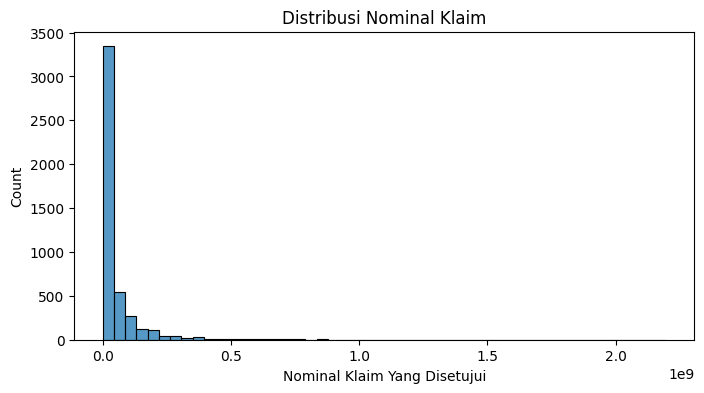

In [14]:
# Distribusi Nominal Klaim
df_klaim["Nominal Klaim Yang Disetujui"].describe()

plt.figure(figsize=(8,4))
sns.histplot(df_klaim["Nominal Klaim Yang Disetujui"], bins=50)
plt.title("Distribusi Nominal Klaim")
plt.show()

In [15]:
# Mean & Median

mean_claim = df_klaim["Nominal Klaim Yang Disetujui"].mean()
median_claim = df_klaim["Nominal Klaim Yang Disetujui"].median()

print("Mean:", mean_claim)
print("Median:", median_claim)

Mean: 55028924.47654551
Median: 14467899.0


In [16]:
# Heavy Tail Check
skewness = df_klaim["Nominal Klaim Yang Disetujui"].skew()
print("Skewness:", skewness)

Skewness: 6.639577239535922


In [17]:
# Inpatient vs Outpatient
df_klaim.groupby("Inpatient/Outpatient")["Nominal Klaim Yang Disetujui"].mean()

Inpatient/Outpatient
IP     8.349898e+07
ODC    5.954579e+07
ODS    3.057115e+07
OP     2.335173e+07
Name: Nominal Klaim Yang Disetujui, dtype: float64

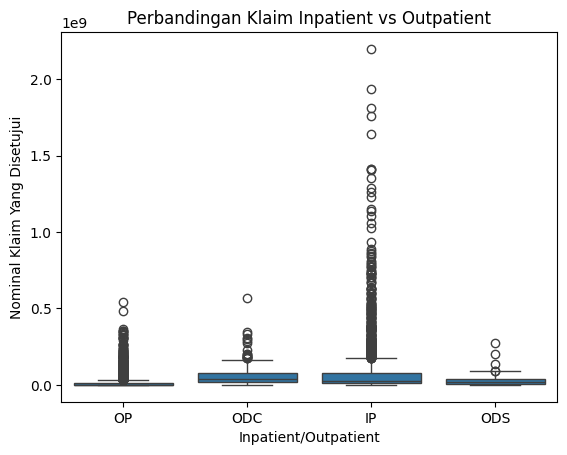

In [18]:
sns.boxplot(
    x="Inpatient/Outpatient",
    y="Nominal Klaim Yang Disetujui",
    data=df_klaim
)
plt.title("Perbandingan Klaim Inpatient vs Outpatient")
plt.show()

In [19]:
# cashless vs reimburse

df_klaim.groupby("Reimburse/Cashless")["Nominal Klaim Yang Disetujui"].mean()

Reimburse/Cashless
C    5.074534e+07
R    5.802680e+07
Name: Nominal Klaim Yang Disetujui, dtype: float64

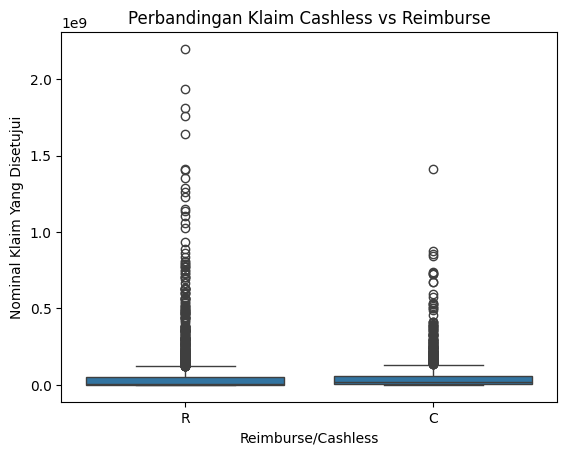

In [20]:
sns.boxplot(
    x="Reimburse/Cashless",
    y="Nominal Klaim Yang Disetujui",
    data=df_klaim
)

plt.title("Perbandingan Klaim Cashless vs Reimburse")
plt.show()

In [21]:
# Tren Klaim 2024-2025

df_klaim["tahun_klaim"] = df_klaim["Tanggal Pasien Masuk RS"].dt.year
df_klaim["tahun_klaim"].value_counts()

tahun_klaim
2024    2990
2025    1637
Name: count, dtype: int64

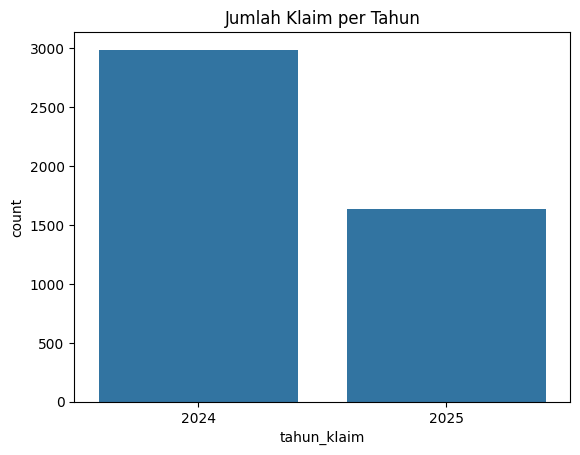

In [22]:
sns.countplot(x="tahun_klaim", data=df_klaim)
plt.title("Jumlah Klaim per Tahun")
plt.show()

In [23]:
# Lama rawat inap
df_klaim["lama_rawat"] = (
    df_klaim["Tanggal Pasien Keluar RS"] - df_klaim["Tanggal Pasien Masuk RS"]
).dt.days
df_klaim["lama_rawat"].describe()

count    4627.000000
mean        1.264102
std         2.930572
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        54.000000
Name: lama_rawat, dtype: float64

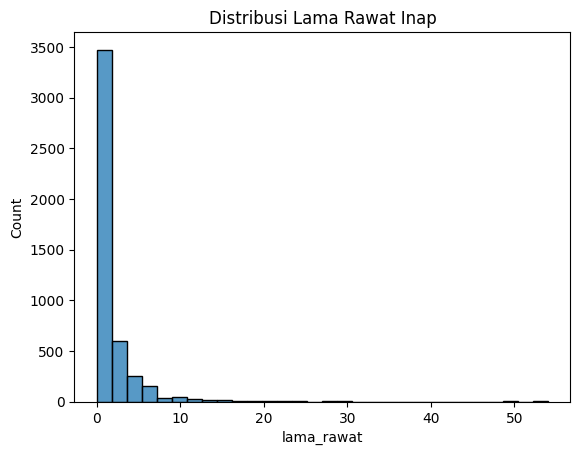

In [24]:
sns.histplot(df_klaim["lama_rawat"], bins=30)
plt.title("Distribusi Lama Rawat Inap")
plt.show()

### Evaluasi Kualitas Data Klaim

In [25]:
# Missing Values
df_klaim.isnull().sum()

Claim ID                          0
Nomor Polis                       0
Reimburse/Cashless                0
Inpatient/Outpatient             37
ICD Diagnosis                     6
ICD Description                   6
Status Klaim                      0
Tanggal Pembayaran Klaim         37
Tanggal Pasien Masuk RS           0
Tanggal Pasien Keluar RS          0
Nominal Klaim Yang Disetujui      0
Nominal Biaya RS Yang Terjadi     0
Lokasi RS                         7
tahun_klaim                       0
lama_rawat                        0
dtype: int64

In [26]:
# Duplikasi Data
df_klaim["Claim ID"].duplicated().sum()

np.int64(0)

In [27]:
# Inkonsistensi Tanggal
df_klaim[df_klaim["Tanggal Pasien Keluar RS"] < df_klaim["Tanggal Pasien Masuk RS"]]

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,tahun_klaim,lama_rawat


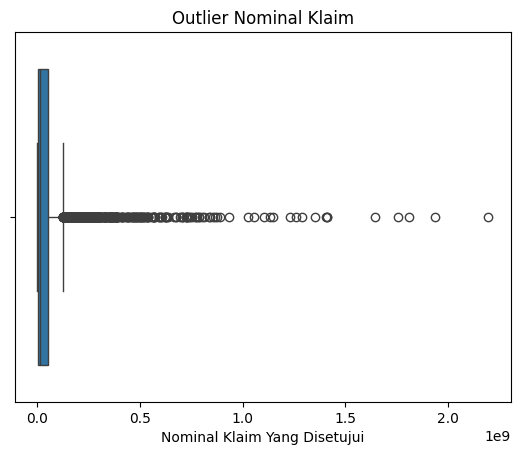

In [28]:
# Outlier Ekstrem
sns.boxplot(x=df_klaim["Nominal Klaim Yang Disetujui"])
plt.title("Outlier Nominal Klaim")
plt.show()

## Analisis Data Polis

### Deskripsi Struktur Data Polis

In [29]:
print("Jumlah data polis:", df_polis.shape[0])
print("Jumlah variabel:", df_polis.shape[1])

Jumlah data polis: 4096
Jumlah variabel: 6


In [30]:
# Kolom
df_polis.columns

Index(['Nomor Polis', 'Plan Code', 'Gender', 'Tanggal Lahir',
       'Tanggal Efektif Polis', 'Domisili'],
      dtype='str')

In [31]:
# Tipe Data

df_polis.info()

<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Nomor Polis            4096 non-null   str  
 1   Plan Code              4096 non-null   str  
 2   Gender                 4096 non-null   str  
 3   Tanggal Lahir          4096 non-null   int64
 4   Tanggal Efektif Polis  4096 non-null   int64
 5   Domisili               4096 non-null   str  
dtypes: int64(2), str(4)
memory usage: 192.1 KB


In [32]:
# Primary Key Check

df_polis["Nomor Polis"].nunique()

4096

### Deskripsi Variabel Data Polis

In [33]:
# Contoh Data
df_polis.head()

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA


In [34]:
df_polis["Plan Code"].value_counts()
df_polis["Gender"].value_counts()

Gender
M    2097
F    1999
Name: count, dtype: int64

### Eksplorasi Awal Data Polis

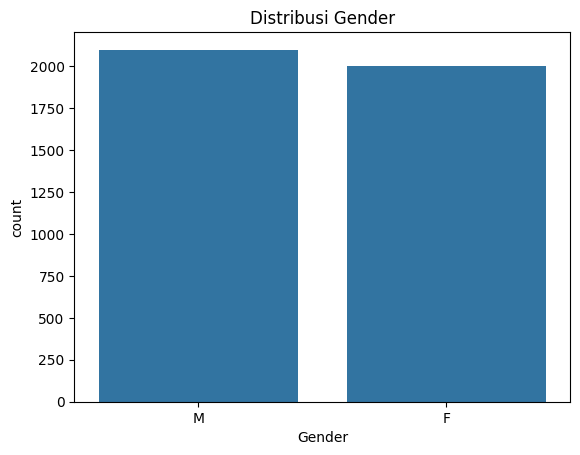

In [35]:
# Distribusi Gender

sns.countplot(x="Gender", data=df_polis)
plt.title("Distribusi Gender")
plt.show()

In [36]:
df_polis["Tanggal Lahir"] = pd.to_datetime(
    df_polis["Tanggal Lahir"].astype(str),
    format="%Y%m%d"
)

df_polis["Tanggal Efektif Polis"] = pd.to_datetime(
    df_polis["Tanggal Efektif Polis"].astype(str),
    format="%Y%m%d"
)

In [37]:
df_polis["Usia"] = (
    (df_polis["Tanggal Efektif Polis"] - df_polis["Tanggal Lahir"])
    .dt.days / 365.25
).round(0)

print(df_polis["Usia"].describe())

count    4096.000000
mean       42.452393
std        16.989077
min         0.000000
25%        33.000000
50%        45.000000
75%        55.000000
max        81.000000
Name: Usia, dtype: float64


In [38]:
usia_count = df_polis["Usia"].value_counts().sort_index().reset_index()
usia_count.columns = ["Usia", "Jumlah"]
usia_count

,Usia,Jumlah
0,0.0,43
1,1.0,36
2,2.0,28
3,3.0,22
4,4.0,20
...,...,...
77,77.0,3
78,78.0,1
79,79.0,2
80,80.0,1


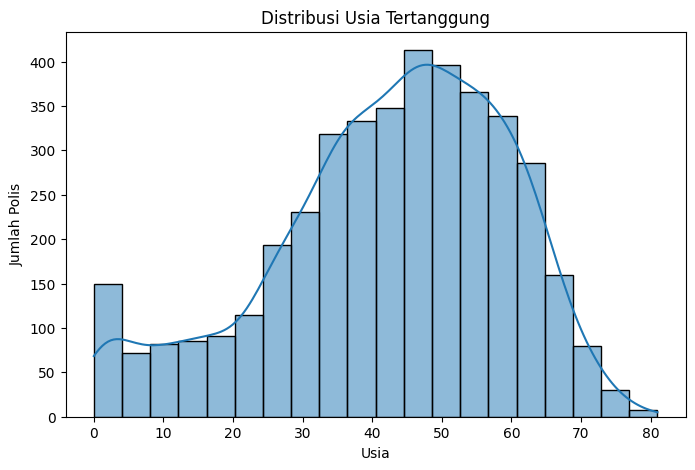

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df_polis["Usia"], bins=20, kde=True)
plt.title("Distribusi Usia Tertanggung")
plt.xlabel("Usia")
plt.ylabel("Jumlah Polis")
plt.show()

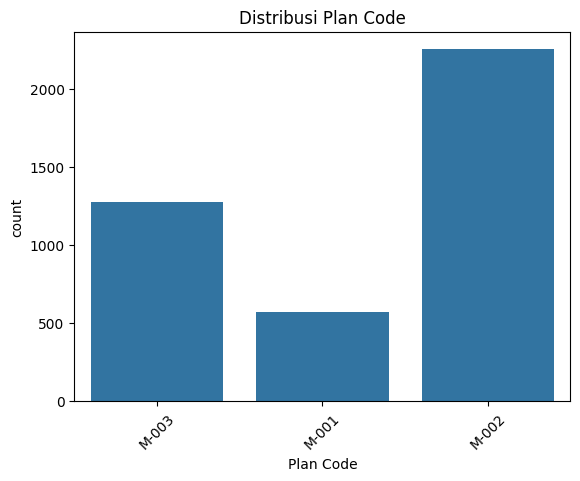

In [40]:
# Distribusi Plan Code
sns.countplot(x="Plan Code", data=df_polis)
plt.title("Distribusi Plan Code")
plt.xticks(rotation=45)
plt.show()

In [41]:
# Distribusi Domisili

df_polis["Domisili"].value_counts().head(10)

Domisili
SURABAYA      1439
JAKARTA       1191
MAKASSAR       305
TANGERANG      299
YOGYAKARTA     201
BANDUNG        167
PALEMBANG      117
BALIKPAPAN      98
MANADO          47
SOLO            43
Name: count, dtype: int64

### Evaluasi Kualitas Data Polis

In [42]:
# Missing Values
df_polis.isnull().sum()

Nomor Polis              0
Plan Code                0
Gender                   0
Tanggal Lahir            0
Tanggal Efektif Polis    0
Domisili                 0
Usia                     0
dtype: int64

In [43]:
# Duplikasi Nomor Polis
df_polis["Nomor Polis"].duplicated().sum()

np.int64(0)

In [44]:
# Inkonsistensi Format

df_polis["Gender"].unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

## Data Preparation

### Selecting Data

In [45]:
from pathlib import Path
import pandas as pd

print("=== NODE S1: LOAD RAW DATA ===")

if "df_klaim" not in globals():
    DATA_DIR = Path(r"D:\SEMESTER 6\MCFITB\3JutaCash\dataset")
    df_klaim = pd.read_csv(DATA_DIR / "Data_Klaim.csv")

if "df_polis" not in globals():
    DATA_DIR = Path(r"D:\SEMESTER 6\MCFITB\3JutaCash\dataset")
    df_polis = pd.read_csv(DATA_DIR / "Data_Polis.csv")

print("df_klaim shape:", df_klaim.shape)
print("df_polis shape:", df_polis.shape)
print("Kolom df_klaim:", df_klaim.columns.tolist())
print("Kolom df_polis:", df_polis.columns.tolist())
print()

=== NODE S1: LOAD RAW DATA ===
df_klaim shape: (4627, 15)
df_polis shape: (4096, 7)
Kolom df_klaim: ['Claim ID', 'Nomor Polis', 'Reimburse/Cashless', 'Inpatient/Outpatient', 'ICD Diagnosis', 'ICD Description', 'Status Klaim', 'Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS', 'Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi', 'Lokasi RS', 'tahun_klaim', 'lama_rawat']
Kolom df_polis: ['Nomor Polis', 'Plan Code', 'Gender', 'Tanggal Lahir', 'Tanggal Efektif Polis', 'Domisili', 'Usia']



In [46]:
# ============================================================
# NODE S2 — MINIMAL TYPING + SCREENING HELPERS
# Tujuan:
# - tanggal claim jadi datetime
# - nominal klaim & biaya RS jadi integer sementara (sesuai keputusanmu)
# - policy dates diparse robust agar helper usia/tenure bisa dihitung
# - buat helper screening (tidak final, hanya untuk selecting)
# ============================================================
print("=== NODE S2: MINIMAL TYPING + SCREENING HELPERS ===")

# ---- 2.1 Klaim: parse tanggal
claim_date_cols = ["Tanggal Pembayaran Klaim", "Tanggal Pasien Masuk RS", "Tanggal Pasien Keluar RS"]
for c in claim_date_cols:
    if c in df_klaim.columns:
        df_klaim[c] = pd.to_datetime(df_klaim[c], errors="coerce")

# ---- 2.2 Klaim: numerik sementara jadi integer (sesuai permintaan)
claim_num_cols = ["Nominal Klaim Yang Disetujui", "Nominal Biaya RS Yang Terjadi"]
for c in claim_num_cols:
    if c in df_klaim.columns:
        df_klaim[c] = pd.to_numeric(df_klaim[c], errors="coerce").round().astype("Int64")

# ---- 2.3 Polis: parse tanggal robust
def parse_yyyymmdd_robust(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.replace(r"\D", "", regex=True)
    s = s.where(s.str.len() == 8, np.nan)
    return pd.to_datetime(s, format="%Y%m%d", errors="coerce")

df_polis["Tanggal Lahir"] = parse_yyyymmdd_robust(df_polis["Tanggal Lahir"])
df_polis["Tanggal Efektif Polis"] = parse_yyyymmdd_robust(df_polis["Tanggal Efektif Polis"])

# ---- 2.4 Helper claim-level screening
# pakai tanggal bayar clean sementara untuk screening saja
df_klaim["Tanggal Pembayaran Klaim_Screen"] = df_klaim["Tanggal Pembayaran Klaim"].copy()
df_klaim.loc[df_klaim["Tanggal Pembayaran Klaim_Screen"].isna(), "Tanggal Pembayaran Klaim_Screen"] = df_klaim["Tanggal Pasien Keluar RS"]

# helper bulan
df_klaim["bulan_bayar_screen"] = df_klaim["Tanggal Pembayaran Klaim_Screen"].dt.to_period("M")

# helper lama rawat
df_klaim["lama_rawat_screen"] = (
    df_klaim["Tanggal Pasien Keluar RS"] - df_klaim["Tanggal Pasien Masuk RS"]
).dt.days

# ---- 2.5 Screening merge sementara (hanya untuk hitung helper usia/tenure)
screen_merge_cols = ["Nomor Polis", "Plan Code", "Domisili", "Tanggal Lahir", "Tanggal Efektif Polis"]
screen_claim = df_klaim.merge(
    df_polis[screen_merge_cols],
    on="Nomor Polis",
    how="left",
    validate="many_to_one"
)

# helper usia
screen_claim["Usia_screen"] = (
    (screen_claim["Tanggal Efektif Polis"] - screen_claim["Tanggal Lahir"]).dt.days / 365.25
)

# helper tenure
screen_claim["Tenure_screen_months"] = (
    (screen_claim["Tanggal Pembayaran Klaim_Screen"] - screen_claim["Tanggal Efektif Polis"]).dt.days / 30.4375
)

print("Dtypes penting setelah minimal typing:")
print(df_klaim[claim_date_cols + claim_num_cols].dtypes)
print("\nMissing policy dates after parse:")
print(df_polis[["Tanggal Lahir", "Tanggal Efektif Polis"]].isna().sum())
print()

=== NODE S2: MINIMAL TYPING + SCREENING HELPERS ===
Dtypes penting setelah minimal typing:
Tanggal Pembayaran Klaim         datetime64[us]
Tanggal Pasien Masuk RS          datetime64[us]
Tanggal Pasien Keluar RS         datetime64[us]
Nominal Klaim Yang Disetujui              Int64
Nominal Biaya RS Yang Terjadi             Int64
dtype: object

Missing policy dates after parse:
Tanggal Lahir            0
Tanggal Efektif Polis    0
dtype: int64



In [47]:
# ============================================================
# NODE S3 — CORRELATION SCREENING (PEARSON + SPEARMAN)
# Tujuan:
# - severity claim-level
# - frequency / total / severity monthly-level
# - visualisasi semua hasil korelasi numerik
# ============================================================
print("=== NODE S3: CORRELATION SCREENING (PEARSON + SPEARMAN) ===")

# ------------------------------------------------------------
# 3A. Claim-level screening untuk target severity
# ------------------------------------------------------------
claim_target = "Nominal Klaim Yang Disetujui"

claim_numeric_features = [
    "Nominal Biaya RS Yang Terjadi",
    "lama_rawat_screen",
    "Usia_screen",
    "Tenure_screen_months",
]

claim_numeric_features = [c for c in claim_numeric_features if c in screen_claim.columns]

claim_corr_rows = []
for f in claim_numeric_features:
    temp = screen_claim[[f, claim_target]].dropna().astype("float64")
    if len(temp) > 2:
        pearson_val = temp.corr(method="pearson").iloc[0, 1]
        spearman_val = temp.corr(method="spearman").iloc[0, 1]
    else:
        pearson_val = np.nan
        spearman_val = np.nan

    claim_corr_rows.append({
        "feature": f,
        "target": "Claim_Severity_Target",
        "pearson": pearson_val,
        "spearman": spearman_val
    })

claim_corr_df = pd.DataFrame(claim_corr_rows)

print("Claim-level correlation screening:")
print(claim_corr_df)
print()


=== NODE S3: CORRELATION SCREENING (PEARSON + SPEARMAN) ===
Claim-level correlation screening:
                         feature                 target   pearson  spearman
0  Nominal Biaya RS Yang Terjadi  Claim_Severity_Target  0.939700  0.979660
1              lama_rawat_screen  Claim_Severity_Target  0.405566  0.503418
2                    Usia_screen  Claim_Severity_Target  0.090983  0.132010
3           Tenure_screen_months  Claim_Severity_Target  0.012903  0.030862



In [48]:
# ------------------------------------------------------------
# 3B. Monthly-level screening untuk frequency / total / severity bulanan
# ------------------------------------------------------------
# Agregasi screening minimal dari claim data yang sudah diperkaya helper
monthly_screen = screen_claim.groupby("bulan_bayar_screen").agg(
    Claim_Frequency=("Claim ID", "nunique"),
    Total_Claim=("Nominal Klaim Yang Disetujui", "sum"),
    Claim_Severity=("Nominal Klaim Yang Disetujui", "mean"),
    Unique_Policies=("Nomor Polis", "nunique"),
    Avg_Biaya_RS=("Nominal Biaya RS Yang Terjadi", "mean"),
    Avg_LOS=("lama_rawat_screen", "mean"),
    Avg_Usia=("Usia_screen", "mean"),
    Avg_Tenure_Months=("Tenure_screen_months", "mean"),
).reset_index()

monthly_targets = ["Claim_Frequency", "Total_Claim", "Claim_Severity"]
monthly_features = ["Unique_Policies", "Avg_Biaya_RS", "Avg_LOS", "Avg_Usia", "Avg_Tenure_Months"]

monthly_corr_rows = []
for f in monthly_features:
    for t in monthly_targets:
        temp = monthly_screen[[f, t]].dropna().astype("float64")
        if len(temp) > 2:
            pearson_val = temp.corr(method="pearson").iloc[0, 1]
            spearman_val = temp.corr(method="spearman").iloc[0, 1]
        else:
            pearson_val = np.nan
            spearman_val = np.nan

        monthly_corr_rows.append({
            "feature": f,
            "target": t,
            "pearson": pearson_val,
            "spearman": spearman_val
        })

monthly_corr_df = pd.DataFrame(monthly_corr_rows)

print("Monthly-level correlation screening:")
print(monthly_corr_df)
print()



Monthly-level correlation screening:
              feature           target   pearson  spearman
0     Unique_Policies  Claim_Frequency  0.993334  0.983022
1     Unique_Policies      Total_Claim  0.914987  0.848499
2     Unique_Policies   Claim_Severity  0.211629  0.228124
3        Avg_Biaya_RS  Claim_Frequency  0.308509  0.315652
4        Avg_Biaya_RS      Total_Claim  0.560374  0.627826
5        Avg_Biaya_RS   Claim_Severity  0.987137  0.986087
6             Avg_LOS  Claim_Frequency -0.632617 -0.212174
7             Avg_LOS      Total_Claim -0.514227 -0.120000
8             Avg_LOS   Claim_Severity  0.140955  0.380870
9            Avg_Usia  Claim_Frequency  0.027357  0.029565
10           Avg_Usia      Total_Claim  0.019470  0.033913
11           Avg_Usia   Claim_Severity -0.361430 -0.289565
12  Avg_Tenure_Months  Claim_Frequency -0.177702 -0.255652
13  Avg_Tenure_Months      Total_Claim -0.003366 -0.049565
14  Avg_Tenure_Months   Claim_Severity  0.469469  0.472174



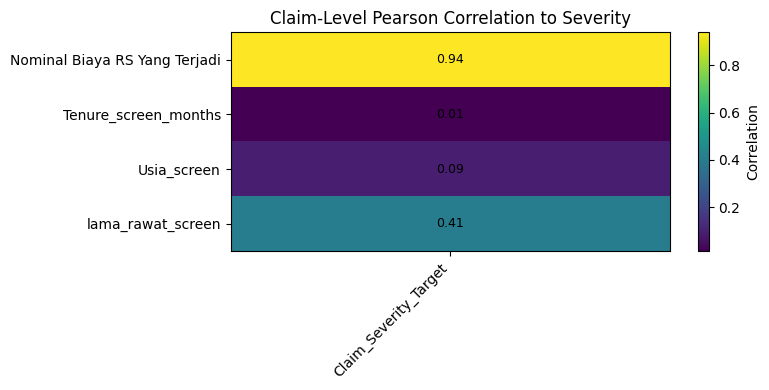

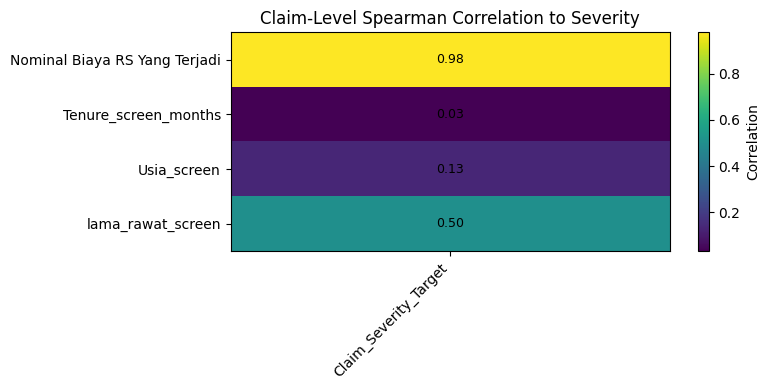

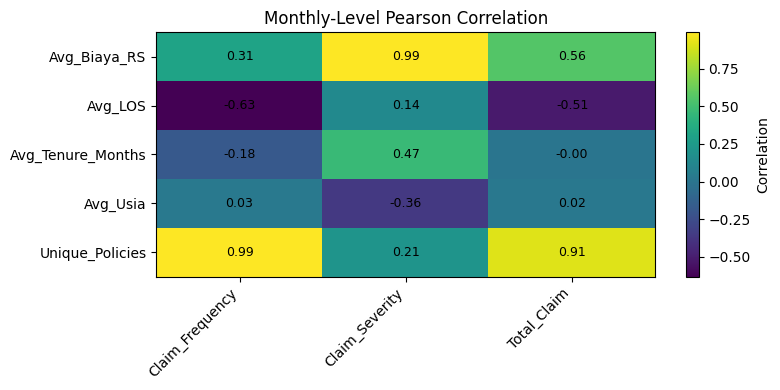

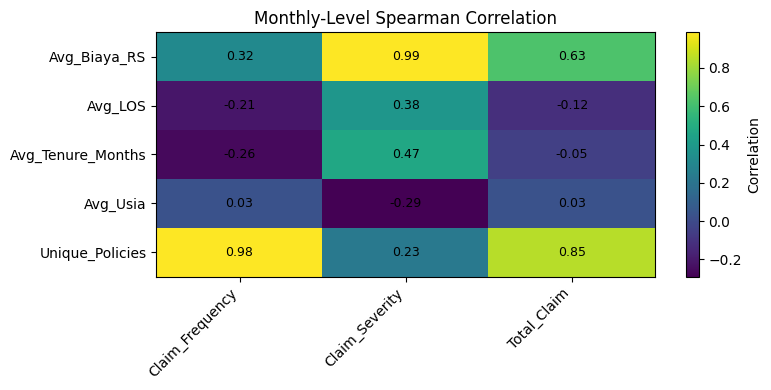

In [49]:
# ------------------------------------------------------------
# 3C. VISUALISASI — helper heatmap matplotlib
# ------------------------------------------------------------
def plot_corr_heatmap(df_pivot, title):
    plt.figure(figsize=(8, max(4, len(df_pivot.index) * 0.6)))
    arr = df_pivot.values.astype(float)

    plt.imshow(arr, aspect="auto")
    plt.colorbar(label="Correlation")

    plt.xticks(range(len(df_pivot.columns)), df_pivot.columns, rotation=45, ha="right")
    plt.yticks(range(len(df_pivot.index)), df_pivot.index)

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            text = "NA" if pd.isna(val) else f"{val:.2f}"
            plt.text(j, i, text, ha="center", va="center", fontsize=9)

    plt.title(title)
    plt.tight_layout()
    plt.show()

# Claim-level Pearson
claim_pearson_pivot = claim_corr_df.pivot(index="feature", columns="target", values="pearson")
plot_corr_heatmap(claim_pearson_pivot, "Claim-Level Pearson Correlation to Severity")

# Claim-level Spearman
claim_spearman_pivot = claim_corr_df.pivot(index="feature", columns="target", values="spearman")
plot_corr_heatmap(claim_spearman_pivot, "Claim-Level Spearman Correlation to Severity")

# Monthly-level Pearson
monthly_pearson_pivot = monthly_corr_df.pivot(index="feature", columns="target", values="pearson")
plot_corr_heatmap(monthly_pearson_pivot, "Monthly-Level Pearson Correlation")

# Monthly-level Spearman
monthly_spearman_pivot = monthly_corr_df.pivot(index="feature", columns="target", values="spearman")
plot_corr_heatmap(monthly_spearman_pivot, "Monthly-Level Spearman Correlation")

In [50]:
# ------------------------------------------------------------
# 3D. Ranking korelasi absolut
# ------------------------------------------------------------
claim_corr_df["max_abs_corr"] = claim_corr_df[["pearson", "spearman"]].abs().max(axis=1)
monthly_corr_df["max_abs_corr"] = monthly_corr_df[["pearson", "spearman"]].abs().max(axis=1)

print("Top claim-level features by max abs correlation:")
print(claim_corr_df.sort_values("max_abs_corr", ascending=False))
print()

print("Top monthly-level feature-target pairs by max abs correlation:")
print(monthly_corr_df.sort_values("max_abs_corr", ascending=False))
print()


Top claim-level features by max abs correlation:
                         feature                 target   pearson  spearman  \
0  Nominal Biaya RS Yang Terjadi  Claim_Severity_Target  0.939700  0.979660   
1              lama_rawat_screen  Claim_Severity_Target  0.405566  0.503418   
2                    Usia_screen  Claim_Severity_Target  0.090983  0.132010   
3           Tenure_screen_months  Claim_Severity_Target  0.012903  0.030862   

   max_abs_corr  
0      0.979660  
1      0.503418  
2      0.132010  
3      0.030862  

Top monthly-level feature-target pairs by max abs correlation:
              feature           target   pearson  spearman  max_abs_corr
0     Unique_Policies  Claim_Frequency  0.993334  0.983022      0.993334
5        Avg_Biaya_RS   Claim_Severity  0.987137  0.986087      0.987137
1     Unique_Policies      Total_Claim  0.914987  0.848499      0.914987
6             Avg_LOS  Claim_Frequency -0.632617 -0.212174      0.632617
4        Avg_Biaya_RS      Total_Cla

In [51]:
# ============================================================
# NODE S4 — FEATURE REGISTRY + LABEL KEEP/REVIEW/DROP
# Korelasi dihitung dulu, baru dipakai sebagai dasar label
# ============================================================
print("=== NODE S4: FEATURE REGISTRY + LABEL ===")

# helper ambil korelasi maksimum per fitur untuk severity claim-level
claim_feature_corr_map = (
    claim_corr_df.groupby("feature")["max_abs_corr"].max().to_dict()
)

# helper ambil korelasi maksimum per fitur untuk monthly targets
monthly_feature_corr_map = (
    monthly_corr_df.groupby("feature")["max_abs_corr"].max().to_dict()
)

def assign_feature_label(feature_name, dataset_name, is_constant=False):
    """
    Label final:
    - KEEP
    - REVIEW
    - DROP
    Korelasi dipakai dulu untuk fitur numerik/helper.
    """

    # DROP rules
    if feature_name == "ICD Description":
        return "DROP", False, "Redundan terhadap ICD Diagnosis dan terlalu noisy."

    if feature_name == "Gender":
        return "DROP", False, "Field sensitif; tidak dipakai dalam fitur final."

    if is_constant:
        return "DROP", False, "Variasi nol/konstan; tidak memberi sinyal ke model."

    # REVIEW keys
    if feature_name in ["Claim ID", "Nomor Polis"]:
        return "REVIEW", True, "Key untuk audit/integrasi; bukan fitur model langsung."

    # Date features: keep karena penting untuk derivation
    if feature_name in [
        "Tanggal Pembayaran Klaim",
        "Tanggal Pasien Masuk RS",
        "Tanggal Pasien Keluar RS",
        "Tanggal Lahir",
        "Tanggal Efektif Polis"
    ]:
        return "KEEP", True, "Dibutuhkan untuk time index / LOS / usia / tenure."

    # Kategori penting: keep berdasarkan business relevance
    if feature_name in [
        "Plan Code", "Domisili",
        "Reimburse/Cashless", "Inpatient/Outpatient",
        "ICD Diagnosis", "Lokasi RS"
    ]:
        return "KEEP", True, "Relevan bisnis; nanti divalidasi lagi oleh SHAP/LIME."

    # Status klaim: review
    if feature_name == "Status Klaim":
        return "REVIEW", True, "Status administrasi; disimpan dulu untuk review."

    # Numerik inti
    if feature_name == "Nominal Klaim Yang Disetujui":
        return "KEEP", True, "Target severity / dasar total claim."

    if feature_name == "Nominal Biaya RS Yang Terjadi":
        corr_val = claim_feature_corr_map.get(feature_name, np.nan)
        if pd.isna(corr_val):
            return "REVIEW", True, "Numerik penting tetapi korelasi awal belum stabil."
        elif corr_val >= 0.30:
            return "KEEP", True, "Numerik penting dengan korelasi awal cukup kuat."
        elif corr_val >= 0.10:
            return "REVIEW", True, "Numerik penting; korelasi awal moderat."
        else:
            return "REVIEW", True, "Numerik penting; korelasi awal lemah tapi bisa nonlinear."

    return "REVIEW", True, "Perlu review lanjutan."

registry_rows = []

# Registry untuk kolom raw klaim
for c in df_klaim.columns:
    is_constant = (df_klaim[c].nunique(dropna=False) <= 1)
    missing_pct = float(df_klaim[c].isna().mean() * 100)

    # correlation max hanya untuk fitur yang memang numerik/helper claim-level
    corr_claim = claim_feature_corr_map.get(c, np.nan)

    label, keep_in_dataset, reason = assign_feature_label(
        feature_name=c,
        dataset_name="klaim",
        is_constant=is_constant
    )

    registry_rows.append({
        "dataset": "klaim",
        "feature": c,
        "missing_pct": round(missing_pct, 4),
        "n_unique": int(df_klaim[c].nunique(dropna=True)),
        "claim_severity_max_abs_corr": None if pd.isna(corr_claim) else float(round(corr_claim, 6)),
        "selection_label": label,
        "keep_in_dataset": keep_in_dataset,
        "reason": reason
    })

# Registry untuk helper features (supaya keputusan selecting lebih jelas)
helper_features = {
    "lama_rawat_screen": claim_feature_corr_map.get("lama_rawat_screen", np.nan),
    "Usia_screen": claim_feature_corr_map.get("Usia_screen", np.nan),
    "Tenure_screen_months": claim_feature_corr_map.get("Tenure_screen_months", np.nan),
    "Unique_Policies": monthly_feature_corr_map.get("Unique_Policies", np.nan),
    "Avg_Biaya_RS": monthly_feature_corr_map.get("Avg_Biaya_RS", np.nan),
    "Avg_LOS": monthly_feature_corr_map.get("Avg_LOS", np.nan),
    "Avg_Usia": monthly_feature_corr_map.get("Avg_Usia", np.nan),
    "Avg_Tenure_Months": monthly_feature_corr_map.get("Avg_Tenure_Months", np.nan),
}

for feat, corr_val in helper_features.items():
    registry_rows.append({
        "dataset": "helper_screening",
        "feature": feat,
        "missing_pct": None,
        "n_unique": None,
        "claim_severity_max_abs_corr": None if pd.isna(corr_val) else float(round(corr_val, 6)),
        "selection_label": "KEEP" if (not pd.isna(corr_val) and corr_val >= 0.10) else "REVIEW",
        "keep_in_dataset": True,
        "reason": "Helper screening untuk memutuskan fitur turunan di tahap constructing."
    })

# Registry untuk polis raw
for c in df_polis.columns:
    is_constant = (df_polis[c].nunique(dropna=False) <= 1)
    missing_pct = float(df_polis[c].isna().mean() * 100)

    label, keep_in_dataset, reason = assign_feature_label(
        feature_name=c,
        dataset_name="polis",
        is_constant=is_constant
    )

    registry_rows.append({
        "dataset": "polis",
        "feature": c,
        "missing_pct": round(missing_pct, 4),
        "n_unique": int(df_polis[c].nunique(dropna=True)),
        "claim_severity_max_abs_corr": None,
        "selection_label": label,
        "keep_in_dataset": keep_in_dataset,
        "reason": reason
    })

feature_registry = pd.DataFrame(registry_rows)

print("Feature registry summary:")
print(feature_registry[[
    "dataset", "feature", "claim_severity_max_abs_corr",
    "selection_label", "keep_in_dataset"
]])
print()

=== NODE S4: FEATURE REGISTRY + LABEL ===
Feature registry summary:
             dataset                          feature  \
0              klaim                         Claim ID   
1              klaim                      Nomor Polis   
2              klaim               Reimburse/Cashless   
3              klaim             Inpatient/Outpatient   
4              klaim                    ICD Diagnosis   
5              klaim                  ICD Description   
6              klaim                     Status Klaim   
7              klaim         Tanggal Pembayaran Klaim   
8              klaim          Tanggal Pasien Masuk RS   
9              klaim         Tanggal Pasien Keluar RS   
10             klaim     Nominal Klaim Yang Disetujui   
11             klaim    Nominal Biaya RS Yang Terjadi   
12             klaim                        Lokasi RS   
13             klaim                      tahun_klaim   
14             klaim                       lama_rawat   
15             klaim

In [52]:
# ============================================================
# NODE S5 — APPLY SELECTING DECISIONS
# - pakai keep_in_dataset = True
# - filter rows non-negative + observation window
# ============================================================
print("=== NODE S5: APPLY SELECTING DECISIONS ===")

claim_keep_cols = feature_registry[
    (feature_registry["dataset"] == "klaim") &
    (feature_registry["keep_in_dataset"] == True)
]["feature"].tolist()

polis_keep_cols = feature_registry[
    (feature_registry["dataset"] == "polis") &
    (feature_registry["keep_in_dataset"] == True)
]["feature"].tolist()

df_klaim = df_klaim[claim_keep_cols].copy()
df_polis = df_polis[polis_keep_cols].copy()

# Data quality row filter minimal
OBS_START = pd.Timestamp("2024-01-01")
OBS_END   = pd.Timestamp("2025-07-31")

before_rows = len(df_klaim)

mask_nonneg = (
    df_klaim["Nominal Klaim Yang Disetujui"].isna() |
    (df_klaim["Nominal Klaim Yang Disetujui"] >= 0)
) & (
    df_klaim["Nominal Biaya RS Yang Terjadi"].isna() |
    (df_klaim["Nominal Biaya RS Yang Terjadi"] >= 0)
)

mask_obs = (
    df_klaim["Tanggal Pasien Masuk RS"].isna() |
    (
        (df_klaim["Tanggal Pasien Masuk RS"] >= OBS_START) &
        (df_klaim["Tanggal Pasien Masuk RS"] <= OBS_END)
    )
)

df_klaim = df_klaim.loc[mask_nonneg & mask_obs].copy()

print("Selected columns final:")
print("df_klaim:", df_klaim.columns.tolist())
print("df_polis:", df_polis.columns.tolist())
print()

print("Rows before row-filter:", before_rows)
print("Rows after row-filter :", len(df_klaim))
print("Dropped rows:", before_rows - len(df_klaim))
print()

# Optional save registry
# feature_registry.to_csv("selecting_feature_registry.csv", index=False)

=== NODE S5: APPLY SELECTING DECISIONS ===
Selected columns final:
df_klaim: ['Claim ID', 'Nomor Polis', 'Reimburse/Cashless', 'Inpatient/Outpatient', 'ICD Diagnosis', 'Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS', 'Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi', 'Lokasi RS', 'tahun_klaim', 'lama_rawat', 'Tanggal Pembayaran Klaim_Screen', 'bulan_bayar_screen', 'lama_rawat_screen']
df_polis: ['Nomor Polis', 'Plan Code', 'Tanggal Lahir', 'Tanggal Efektif Polis', 'Domisili', 'Usia']

Rows before row-filter: 4627
Rows after row-filter : 4627
Dropped rows: 0



### Cleaning Data


In [53]:
# ============================================================
# NODE C1 — DATA AUDIT (BEFORE CLEANING)
# ============================================================
print("=== NODE C1: DATA AUDIT (BEFORE CLEANING) ===")
print("df_klaim shape:", df_klaim.shape)
print("df_polis shape:", df_polis.shape)

print("\nMissing values df_klaim:")
print(df_klaim.isna().sum())

print("\nMissing values df_polis:")
print(df_polis.isna().sum())

print("\nDtypes df_klaim:")
print(df_klaim.dtypes)

print("\nDtypes df_polis:")
print(df_polis.dtypes)
print()

=== NODE C1: DATA AUDIT (BEFORE CLEANING) ===
df_klaim shape: (4627, 16)
df_polis shape: (4096, 6)

Missing values df_klaim:
Claim ID                            0
Nomor Polis                         0
Reimburse/Cashless                  0
Inpatient/Outpatient               37
ICD Diagnosis                       6
Tanggal Pembayaran Klaim           37
Tanggal Pasien Masuk RS             0
Tanggal Pasien Keluar RS            0
Nominal Klaim Yang Disetujui        0
Nominal Biaya RS Yang Terjadi       0
Lokasi RS                           7
tahun_klaim                         0
lama_rawat                          0
Tanggal Pembayaran Klaim_Screen     0
bulan_bayar_screen                  0
lama_rawat_screen                   0
dtype: int64

Missing values df_polis:
Nomor Polis              0
Plan Code                0
Tanggal Lahir            0
Tanggal Efektif Polis    0
Domisili                 0
Usia                     0
dtype: int64

Dtypes df_klaim:
Claim ID                           

In [54]:
# ============================================================
# NODE C2 — FIX METADATA / TYPE
# - Tanggal -> datetime
# - Nominal -> integer
# - Usia -> integer
# - Semua object -> string
# ============================================================
print("=== NODE C2: FIX METADATA / TYPE ===")

# -------------------------
# 2A. Klaim dates
# -------------------------
claim_date_cols = ["Tanggal Pembayaran Klaim", "Tanggal Pasien Masuk RS", "Tanggal Pasien Keluar RS"]
for c in claim_date_cols:
    if c in df_klaim.columns:
        before_missing = df_klaim[c].isna().sum()
        df_klaim[c] = pd.to_datetime(df_klaim[c], errors="coerce")
        after_missing = df_klaim[c].isna().sum()
        print(f"{c}: missing {before_missing} -> {after_missing}, dtype={df_klaim[c].dtype}")

# -------------------------
# 2B. Polis dates (robust parse yyyymmdd)
# -------------------------
def parse_yyyymmdd_robust(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.replace(r"\D", "", regex=True)
    s = s.where(s.str.len() == 8, np.nan)
    return pd.to_datetime(s, format="%Y%m%d", errors="coerce")

for c in ["Tanggal Lahir", "Tanggal Efektif Polis"]:
    if c in df_polis.columns:
        before_missing = df_polis[c].isna().sum()
        df_polis[c] = parse_yyyymmdd_robust(df_polis[c])
        after_missing = df_polis[c].isna().sum()
        print(f"{c}: missing {before_missing} -> {after_missing}, dtype={df_polis[c].dtype}")

# -------------------------
# 2C. Numeric claim columns -> Int64
# -------------------------
claim_num_cols = ["Nominal Klaim Yang Disetujui", "Nominal Biaya RS Yang Terjadi"]
for c in claim_num_cols:
    if c in df_klaim.columns:
        before_missing = df_klaim[c].isna().sum()
        df_klaim[c] = pd.to_numeric(df_klaim[c], errors="coerce").round().astype("Int64")
        after_missing = df_klaim[c].isna().sum()
        print(f"{c}: missing {before_missing} -> {after_missing}, dtype={df_klaim[c].dtype}")

# -------------------------
# 2D. Usia -> Int64 (kalau ada)
# -------------------------
if "Usia" in df_polis.columns:
    before_missing = df_polis["Usia"].isna().sum()
    df_polis["Usia"] = pd.to_numeric(df_polis["Usia"], errors="coerce").round().astype("Int64")
    after_missing = df_polis["Usia"].isna().sum()
    print(f"Usia: missing {before_missing} -> {after_missing}, dtype={df_polis['Usia'].dtype}")

# -------------------------
# 2E. Semua object -> string
# -------------------------
claim_object_cols = df_klaim.select_dtypes(include=["object"]).columns.tolist()
polis_object_cols = df_polis.select_dtypes(include=["object"]).columns.tolist()

for c in claim_object_cols:
    df_klaim[c] = df_klaim[c].astype("string")

for c in polis_object_cols:
    df_polis[c] = df_polis[c].astype("string")

print("\nObject columns converted to string - df_klaim:")
print(claim_object_cols if claim_object_cols else "Tidak ada")

print("\nObject columns converted to string - df_polis:")
print(polis_object_cols if polis_object_cols else "Tidak ada")

print("\nDtypes after type fix - df_klaim:")
print(df_klaim.dtypes)

print("\nDtypes after type fix - df_polis:")
print(df_polis.dtypes)
print()

=== NODE C2: FIX METADATA / TYPE ===
Tanggal Pembayaran Klaim: missing 37 -> 37, dtype=datetime64[us]
Tanggal Pasien Masuk RS: missing 0 -> 0, dtype=datetime64[us]
Tanggal Pasien Keluar RS: missing 0 -> 0, dtype=datetime64[us]
Tanggal Lahir: missing 0 -> 0, dtype=datetime64[us]
Tanggal Efektif Polis: missing 0 -> 0, dtype=datetime64[us]
Nominal Klaim Yang Disetujui: missing 0 -> 0, dtype=Int64
Nominal Biaya RS Yang Terjadi: missing 0 -> 0, dtype=Int64
Usia: missing 0 -> 0, dtype=Int64

Object columns converted to string - df_klaim:
['Claim ID', 'Nomor Polis', 'Reimburse/Cashless', 'Inpatient/Outpatient', 'ICD Diagnosis', 'Lokasi RS']

Object columns converted to string - df_polis:
['Nomor Polis', 'Plan Code', 'Domisili']

Dtypes after type fix - df_klaim:
Claim ID                                   string
Nomor Polis                                string
Reimburse/Cashless                         string
Inpatient/Outpatient                       string
ICD Diagnosis                     

C:\Users\LEGION\AppData\Local\Temp\ipykernel_10476\638627422.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  claim_object_cols = df_klaim.select_dtypes(include=["object"]).columns.tolist()
C:\Users\LEGION\AppData\Local\Temp\ipykernel_10476\638627422.py:60: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.

In [55]:
# ============================================================
# NODE C3 — DATA ERRORS: DROP CLEARLY INVALID
# - nominal negatif
# - tanggal keluar < tanggal masuk
# ============================================================
print("=== NODE C3: DATA ERRORS (DROP CLEARLY INVALID) ===")

# -------------------------
# 3A. Drop nominal negatif
# -------------------------
before_rows = len(df_klaim)

mask_nonneg = (
    (df_klaim["Nominal Klaim Yang Disetujui"].isna() | (df_klaim["Nominal Klaim Yang Disetujui"] >= 0)) &
    (df_klaim["Nominal Biaya RS Yang Terjadi"].isna() | (df_klaim["Nominal Biaya RS Yang Terjadi"] >= 0))
)

dropped_neg = df_klaim.loc[
    ~mask_nonneg,
    ["Claim ID", "Nomor Polis", "Nominal Klaim Yang Disetujui", "Nominal Biaya RS Yang Terjadi"]
].head(10)

df_klaim = df_klaim.loc[mask_nonneg].copy()

print("Dropped rows (negative amounts):", before_rows - len(df_klaim))
print("Preview dropped negative rows (max 10):")
print(dropped_neg if len(dropped_neg) > 0 else "Tidak ada")
print()

=== NODE C3: DATA ERRORS (DROP CLEARLY INVALID) ===
Dropped rows (negative amounts): 0
Preview dropped negative rows (max 10):
Tidak ada



In [56]:

# -------------------------
# 3B. Drop tanggal tidak logis
# -------------------------
before_rows = len(df_klaim)

mask_date_ok = (
    df_klaim["Tanggal Pasien Masuk RS"].isna() |
    df_klaim["Tanggal Pasien Keluar RS"].isna() |
    (df_klaim["Tanggal Pasien Keluar RS"] >= df_klaim["Tanggal Pasien Masuk RS"])
)

dropped_date = df_klaim.loc[
    ~mask_date_ok,
    ["Claim ID", "Nomor Polis", "Tanggal Pasien Masuk RS", "Tanggal Pasien Keluar RS"]
].head(10)

df_klaim = df_klaim.loc[mask_date_ok].copy()

print("Dropped rows (tanggal keluar < tanggal masuk):", before_rows - len(df_klaim))
print("Preview dropped date-error rows (max 10):")
print(dropped_date if len(dropped_date) > 0 else "Tidak ada")
print()

Dropped rows (tanggal keluar < tanggal masuk): 0
Preview dropped date-error rows (max 10):
Tidak ada



In [57]:
# -------------------------
# 3B. Drop tanggal tidak logis
# -------------------------
before_rows = len(df_klaim)

mask_date_ok = (
    df_klaim["Tanggal Pasien Masuk RS"].isna() |
    df_klaim["Tanggal Pasien Keluar RS"].isna() |
    (df_klaim["Tanggal Pasien Keluar RS"] >= df_klaim["Tanggal Pasien Masuk RS"])
)

dropped_date = df_klaim.loc[
    ~mask_date_ok,
    ["Claim ID", "Nomor Polis", "Tanggal Pasien Masuk RS", "Tanggal Pasien Keluar RS"]
].head(10)

df_klaim = df_klaim.loc[mask_date_ok].copy()

print("Dropped rows (tanggal keluar < tanggal masuk):", before_rows - len(df_klaim))
print("Preview dropped date-error rows (max 10):")
print(dropped_date if len(dropped_date) > 0 else "Tidak ada")
print()

Dropped rows (tanggal keluar < tanggal masuk): 0
Preview dropped date-error rows (max 10):
Tidak ada



In [58]:
# ============================================================
# NODE C5 — MISSING VALUE HANDLING
# - numerikal -> imputasi median
# - kategori -> UNKNOWN
# - Tanggal Pembayaran Klaim -> overwrite dengan Tanggal Pasien Keluar RS
# ============================================================
print("=== NODE C5: MISSING VALUE HANDLING ===")

# -------------------------
# 5A. Missing numerikal -> median
# -------------------------
for c in claim_num_cols:
    if c in df_klaim.columns:
        before_missing = int(df_klaim[c].isna().sum())
        if before_missing > 0:
            med = df_klaim[c].dropna().astype("float64").median()
            df_klaim[c] = df_klaim[c].fillna(int(round(med))).astype("Int64")
        after_missing = int(df_klaim[c].isna().sum())
        print(f"{c}: missing {before_missing} -> {after_missing}")

# -------------------------
# 5B. Missing kategori -> UNKNOWN
# -------------------------
cat_fill_cols = [c for c in [
    "Reimburse/Cashless", "Inpatient/Outpatient", "ICD Diagnosis", "Lokasi RS", "Status Klaim"
] if c in df_klaim.columns]

for c in cat_fill_cols:
    before_missing = int(df_klaim[c].isna().sum())
    df_klaim[c] = df_klaim[c].fillna("UNKNOWN").astype("string")
    after_missing = int(df_klaim[c].isna().sum())
    print(f"{c}: missing {before_missing} -> {after_missing}")

# -------------------------
# 5C. Missing Tanggal Pembayaran Klaim -> overwrite dengan Tanggal Pasien Keluar RS
# -------------------------
if "Tanggal Pembayaran Klaim" in df_klaim.columns and "Tanggal Pasien Keluar RS" in df_klaim.columns:
    before_missing = int(df_klaim["Tanggal Pembayaran Klaim"].isna().sum())
    df_klaim["Tanggal Pembayaran Klaim"] = df_klaim["Tanggal Pembayaran Klaim"].fillna(
        df_klaim["Tanggal Pasien Keluar RS"]
    )
    after_missing = int(df_klaim["Tanggal Pembayaran Klaim"].isna().sum())
    print(f"Tanggal Pembayaran Klaim: missing {before_missing} -> {after_missing}")

print()


=== NODE C5: MISSING VALUE HANDLING ===
Nominal Klaim Yang Disetujui: missing 0 -> 0
Nominal Biaya RS Yang Terjadi: missing 0 -> 0
Reimburse/Cashless: missing 0 -> 0
Inpatient/Outpatient: missing 37 -> 0
ICD Diagnosis: missing 6 -> 0
Lokasi RS: missing 7 -> 0
Tanggal Pembayaran Klaim: missing 37 -> 0



In [59]:
# ============================================================
# NODE C6 — CLEANUP: DROP SCREEN / HELPER COLUMNS
# Tujuan:
# - hasil akhir cleaning hanya menyisakan kolom inti yang sudah dibersihkan
# - kolom screening/helper tidak dibawa ke tahap berikutnya
# ============================================================
print("=== NODE C6: CLEANUP (DROP SCREEN / HELPER COLUMNS) ===")

drop_helper_cols = [
    "Tanggal Pembayaran Klaim_Screen",
    "bulan_bayar_screen",
    "lama_rawat_screen",
    "tahun_klaim",
    "lama_rawat"
]

# drop hanya kolom yang memang ada
drop_helper_cols = [c for c in drop_helper_cols if c in df_klaim.columns]

print("Kolom helper yang akan di-drop:")
print(drop_helper_cols if drop_helper_cols else "Tidak ada kolom helper untuk di-drop.")

df_klaim = df_klaim.drop(columns=drop_helper_cols)

print("\nKolom df_klaim setelah cleanup:")
print(df_klaim.columns.tolist())
print("Shape df_klaim setelah cleanup:", df_klaim.shape)
print()

=== NODE C6: CLEANUP (DROP SCREEN / HELPER COLUMNS) ===
Kolom helper yang akan di-drop:
['Tanggal Pembayaran Klaim_Screen', 'bulan_bayar_screen', 'lama_rawat_screen', 'tahun_klaim', 'lama_rawat']

Kolom df_klaim setelah cleanup:
['Claim ID', 'Nomor Polis', 'Reimburse/Cashless', 'Inpatient/Outpatient', 'ICD Diagnosis', 'Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS', 'Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi', 'Lokasi RS']
Shape df_klaim setelah cleanup: (4627, 11)



In [60]:
# ============================================================
# NODE C7 — DATA AUDIT (AFTER CLEANING)
# ============================================================
print("=== NODE C7: DATA AUDIT (AFTER CLEANING) ===")
print("df_klaim shape:", df_klaim.shape)
print("df_polis shape:", df_polis.shape)

print("\nMissing values df_klaim after cleaning:")
print(df_klaim.isna().sum())

print("\nMissing values df_polis after cleaning:")
print(df_polis.isna().sum())

print("\nSample df_klaim after cleaning (5 rows):")
print(df_klaim.head(5))

print("\nSample df_polis after cleaning (5 rows):")
print(df_polis.head(5))

print("\nFinal dtypes df_klaim:")
print(df_klaim.dtypes)

print("\nFinal dtypes df_polis:")
print(df_polis.dtypes)

print("\nDONE - CLEANING DATA FINISHED.")

=== NODE C7: DATA AUDIT (AFTER CLEANING) ===
df_klaim shape: (4627, 11)
df_polis shape: (4096, 6)

Missing values df_klaim after cleaning:
Claim ID                         0
Nomor Polis                      0
Reimburse/Cashless               0
Inpatient/Outpatient             0
ICD Diagnosis                    0
Tanggal Pembayaran Klaim         0
Tanggal Pasien Masuk RS          0
Tanggal Pasien Keluar RS         0
Nominal Klaim Yang Disetujui     0
Nominal Biaya RS Yang Terjadi    0
Lokasi RS                        0
dtype: int64

Missing values df_polis after cleaning:
Nomor Polis              0
Plan Code                0
Tanggal Lahir            0
Tanggal Efektif Polis    0
Domisili                 0
Usia                     0
dtype: int64

Sample df_klaim after cleaning (5 rows):
   Claim ID Nomor Polis Reimburse/Cashless Inpatient/Outpatient ICD Diagnosis  \
0  C-0001-M    POL-0176                  R                   OP           C50   
1  C-0002-M    POL-3288                  R 

### Constructing New Data

In [61]:
# ============================================================
# NODE N1 — INPUT CHECK
# ============================================================
print("=== NODE N1: INPUT CHECK ===")

needed_klaim = [
    "Claim ID", "Nomor Polis",
    "ICD Diagnosis",
    "Tanggal Pembayaran Klaim",
    "Tanggal Pasien Masuk RS",
    "Tanggal Pasien Keluar RS"
]

needed_polis = [
    "Nomor Polis",
    "Tanggal Lahir",
    "Tanggal Efektif Polis"
]

miss_k = [c for c in needed_klaim if c not in df_klaim.columns]
miss_p = [c for c in needed_polis if c not in df_polis.columns]

if miss_k:
    raise ValueError(f"df_klaim missing columns: {miss_k}")
if miss_p:
    raise ValueError(f"df_polis missing columns: {miss_p}")

print("df_klaim shape:", df_klaim.shape)
print("df_polis shape:", df_polis.shape)
print("OK - kolom minimum tersedia.\n")

=== NODE N1: INPUT CHECK ===
df_klaim shape: (4627, 11)
df_polis shape: (4096, 6)
OK - kolom minimum tersedia.



In [62]:
# ============================================================
# NODE N2 — CONSTRUCT usia (di df_polis)
# usia = Tanggal Efektif Polis - Tanggal Lahir
# ============================================================
print("=== NODE N2: CONSTRUCT usia ===")

before_has_usia = "usia" in df_polis.columns
if before_has_usia:
    print("NOTE: kolom 'usia' sudah ada dan akan di-overwrite.")

usia_raw = (
    (df_polis["Tanggal Efektif Polis"] - df_polis["Tanggal Lahir"]).dt.days / 365.25
)

# usia negatif dianggap tidak valid
usia_raw = usia_raw.where(usia_raw >= 0, np.nan)

df_polis["usia"] = usia_raw.round().astype("Int64")

print("Missing usia:", int(df_polis["usia"].isna().sum()))
print("Sample usia (5 rows):")
print(df_polis[["Nomor Polis", "Tanggal Lahir", "Tanggal Efektif Polis", "usia"]].head(5))
print()

=== NODE N2: CONSTRUCT usia ===
Missing usia: 0
Sample usia (5 rows):
  Nomor Polis Tanggal Lahir Tanggal Efektif Polis  usia
0    POL-0001    1964-08-11            2014-06-03    50
1    POL-0002    1971-07-30            2014-06-03    43
2    POL-0003    1979-08-21            2016-08-08    37
3    POL-0004    2014-07-24            2016-08-11     2
4    POL-0005    1981-01-14            2015-08-28    35



In [63]:
# ============================================================
# NODE N3 — CONSTRUCT lama_rawat (di df_klaim)
# lama_rawat = Tanggal Keluar RS - Tanggal Masuk RS
# ============================================================
print("=== NODE N3: CONSTRUCT lama_rawat ===")

before_has_los = "lama_rawat" in df_klaim.columns
if before_has_los:
    print("NOTE: kolom 'lama_rawat' sudah ada dan akan di-overwrite.")

los_raw = (
    df_klaim["Tanggal Pasien Keluar RS"] - df_klaim["Tanggal Pasien Masuk RS"]
).dt.days

# lama rawat negatif dianggap tidak valid
los_raw = los_raw.where(los_raw >= 0, np.nan)

df_klaim["lama_rawat"] = los_raw.round().astype("Int64")

print("Missing lama_rawat:", int(df_klaim["lama_rawat"].isna().sum()))
print("Descriptive stats lama_rawat:")
print(df_klaim["lama_rawat"].astype("float64").describe())
print()

=== NODE N3: CONSTRUCT lama_rawat ===
Missing lama_rawat: 0
Descriptive stats lama_rawat:
count    4627.000000
mean        1.264102
std         2.930572
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        54.000000
Name: lama_rawat, dtype: float64



In [64]:
# ============================================================
# NODE N4 — CONSTRUCT ICD3 (di df_klaim)
# ICD3 = 3 karakter awal sebelum titik
# contoh:
# - C18.9 -> C18
# - C50   -> C50
# - UNKNOWN -> UNKNOWN
# ============================================================
print("=== NODE N4: CONSTRUCT ICD3 ===")

def make_icd3(code):
    if pd.isna(code):
        return np.nan
    s = str(code).strip().upper()
    if s == "UNKNOWN":
        return "UNKNOWN"
    root = s.split(".")[0]
    return root[:3]

df_klaim["ICD3"] = df_klaim["ICD Diagnosis"].map(make_icd3).astype("string")

print("Unique ICD Diagnosis:", int(df_klaim["ICD Diagnosis"].nunique(dropna=True)))
print("Unique ICD3:", int(df_klaim["ICD3"].nunique(dropna=True)))
print("Top ICD3:")
print(df_klaim["ICD3"].value_counts(dropna=False).head(10))
print()


=== NODE N4: CONSTRUCT ICD3 ===
Unique ICD Diagnosis: 754
Unique ICD3: 396
Top ICD3:
ICD3
N18    437
H26    289
C50    262
K29    185
C34    163
I25    131
H35    100
R10     85
C18     82
H25     78
Name: count, dtype: Int64



In [65]:
# ============================================================
# NODE N5 — CONSTRUCT bulan_bayar (di df_klaim)
# bulan_bayar = YYYY-MM dari Tanggal Pembayaran Klaim
# Disimpan sebagai string agar aman untuk export / modeling lanjutan
# ============================================================
print("=== NODE N5: CONSTRUCT bulan_bayar ===")

df_klaim["bulan_bayar"] = df_klaim["Tanggal Pembayaran Klaim"].dt.strftime("%Y-%m").astype("string")

print("Missing bulan_bayar:", int(df_klaim["bulan_bayar"].isna().sum()))
print("Top bulan_bayar:")
print(df_klaim["bulan_bayar"].value_counts(dropna=False).head(10))
print()

=== NODE N5: CONSTRUCT bulan_bayar ===
Missing bulan_bayar: 0
Top bulan_bayar:
bulan_bayar
2024-11    365
2024-12    296
2025-01    293
2024-08    285
2025-07    276
2024-09    250
2025-08    245
2024-10    243
2024-05    236
2025-03    234
Name: count, dtype: Int64



In [66]:
# ============================================================
# NODE N6 — CONSTRUCT tenure (di df_klaim)
# tenure = Tanggal Pasien Masuk RS - Tanggal Efektif Polis
# satuan: bulan
# dihitung berdasarkan tanggal kejadian, bukan tanggal pembayaran
# ============================================================
print("=== NODE N6: CONSTRUCT tenure ===")

# map Tanggal Efektif Polis dari df_polis ke df_klaim berdasarkan Nomor Polis
tanggal_efektif_map = df_polis.set_index("Nomor Polis")["Tanggal Efektif Polis"]
effective_for_claim = df_klaim["Nomor Polis"].map(tanggal_efektif_map)

tenure_raw = (
    (df_klaim["Tanggal Pasien Masuk RS"] - effective_for_claim).dt.days / 30.4375
)

# tenure negatif dianggap tidak valid
tenure_raw = tenure_raw.where(tenure_raw >= 0, np.nan)

df_klaim["tenure"] = tenure_raw.round().astype("Int64")

print("Missing tenure:", int(df_klaim["tenure"].isna().sum()))
print("Sample tenure (5 rows):")
print(
    pd.DataFrame({
        "Nomor Polis": df_klaim["Nomor Polis"].head(5),
        "Tanggal Pasien Masuk RS": df_klaim["Tanggal Pasien Masuk RS"].head(5),
        "Tanggal Efektif Polis(mapped)": effective_for_claim.head(5),
        "tenure": df_klaim["tenure"].head(5)
    })
)
print()

=== NODE N6: CONSTRUCT tenure ===
Missing tenure: 0
Sample tenure (5 rows):
  Nomor Polis Tanggal Pasien Masuk RS Tanggal Efektif Polis(mapped)  tenure
0    POL-0176              2024-05-27                    2015-01-09     113
1    POL-3288              2024-07-15                    2012-06-19     145
2    POL-1786              2024-05-16                    2015-03-16     110
3    POL-1786              2024-07-18                    2015-03-16     112
4    POL-2778              2024-06-06                    2014-06-24     119



In [67]:
# ============================================================
# NODE N7 — FINAL AUDIT AFTER CONSTRUCTING
# ============================================================
print("=== NODE N7: FINAL AUDIT AFTER CONSTRUCTING ===")

print("df_klaim shape:", df_klaim.shape)
print("df_polis shape:", df_polis.shape)

print("\nConstructed columns in df_klaim:")
constructed_klaim_cols = [c for c in ["lama_rawat", "ICD3", "bulan_bayar", "tenure"] if c in df_klaim.columns]
print(constructed_klaim_cols)

print("\nConstructed columns in df_polis:")
constructed_polis_cols = [c for c in ["usia"] if c in df_polis.columns]
print(constructed_polis_cols)

print("\nMissing values for constructed columns (df_klaim):")
print(df_klaim[constructed_klaim_cols].isna().sum())

print("\nMissing values for constructed columns (df_polis):")
print(df_polis[constructed_polis_cols].isna().sum())

print("\nSample df_klaim after constructing (5 rows):")
show_cols_klaim = [c for c in [
    "Claim ID", "Nomor Polis", "ICD Diagnosis", "ICD3",
    "Tanggal Pembayaran Klaim", "bulan_bayar",
    "Tanggal Pasien Masuk RS", "Tanggal Pasien Keluar RS",
    "lama_rawat", "tenure"
] if c in df_klaim.columns]
print(df_klaim[show_cols_klaim].head(5))

print("\nSample df_polis after constructing (5 rows):")
show_cols_polis = [c for c in [
    "Nomor Polis", "Tanggal Lahir", "Tanggal Efektif Polis", "usia"
] if c in df_polis.columns]
print(df_polis[show_cols_polis].head(5))

print("\nDONE - CONSTRUCTING DATA FINISHED.")

=== NODE N7: FINAL AUDIT AFTER CONSTRUCTING ===
df_klaim shape: (4627, 15)
df_polis shape: (4096, 7)

Constructed columns in df_klaim:
['lama_rawat', 'ICD3', 'bulan_bayar', 'tenure']

Constructed columns in df_polis:
['usia']

Missing values for constructed columns (df_klaim):
lama_rawat     0
ICD3           0
bulan_bayar    0
tenure         0
dtype: int64

Missing values for constructed columns (df_polis):
usia    0
dtype: int64

Sample df_klaim after constructing (5 rows):
   Claim ID Nomor Polis ICD Diagnosis ICD3 Tanggal Pembayaran Klaim  \
0  C-0001-M    POL-0176           C50  C50               2024-07-08   
1  C-0002-M    POL-3288           C34  C34               2024-08-06   
2  C-0003-M    POL-1786         C18.9  C18               2024-10-17   
3  C-0004-M    POL-1786           C34  C34               2024-09-03   
4  C-0005-M    POL-2778           C50  C50               2024-06-06   

  bulan_bayar Tanggal Pasien Masuk RS Tanggal Pasien Keluar RS  lama_rawat  \
0     2024-07  

### Integrating Data

In [68]:
# ============================================================
# STEP 4: INTEGRATING DATA (FINAL)
# Tujuan:
# - Merge data klaim + polis
# - Bentuk dataset claim-level untuk severity analysis
# - Bentuk dataset monthly-level untuk frequency, severity, nominal claim
#
# Input:
# - df_klaim : hasil Step 3 Constructing
# - df_polis : hasil Step 3 Constructing
#
# Output:
# - df_claim_integrated
# - df_monthly_integrated
# - export CSV
# ============================================================

# ============================================================
# NODE I1 — INPUT CHECK
# ============================================================
print("=== NODE I1: INPUT CHECK ===")

needed_klaim = [
    "Claim ID",
    "Nomor Polis",
    "Nominal Klaim Yang Disetujui",
    "Tanggal Pembayaran Klaim",
    "bulan_bayar",
    "lama_rawat",
    "tenure",
    "ICD3"
]

needed_polis = [
    "Nomor Polis",
    "Plan Code",
    "Domisili",
    "usia"
]

miss_k = [c for c in needed_klaim if c not in df_klaim.columns]
miss_p = [c for c in needed_polis if c not in df_polis.columns]

if miss_k:
    raise ValueError(f"df_klaim missing columns: {miss_k}")
if miss_p:
    raise ValueError(f"df_polis missing columns: {miss_p}")

print("df_klaim shape:", df_klaim.shape)
print("df_polis shape:", df_polis.shape)
print("OK - kolom minimum tersedia.\n")

=== NODE I1: INPUT CHECK ===
df_klaim shape: (4627, 15)
df_polis shape: (4096, 7)
OK - kolom minimum tersedia.



In [69]:
# ============================================================
# NODE I2 — PRE-MERGE AUDIT
# Validasi key polis harus unik
# ============================================================
print("=== NODE I2: PRE-MERGE AUDIT ===")

dup_polis = int(df_polis.duplicated(subset=["Nomor Polis"]).sum())
print("Duplicate Nomor Polis in df_polis:", dup_polis)

if dup_polis > 0:
    sample_dup = df_polis[df_polis.duplicated(subset=["Nomor Polis"], keep=False)] \
        .sort_values("Nomor Polis").head(10)
    raise ValueError(
        "ERROR: 'Nomor Polis' di df_polis tidak unik. Merge dihentikan agar tidak terjadi row explosion.\n"
        + sample_dup.to_string(index=False)
    )

print("Unique Nomor Polis in df_klaim:", int(df_klaim["Nomor Polis"].nunique()))
print("Unique Nomor Polis in df_polis:", int(df_polis["Nomor Polis"].nunique()))
print()


=== NODE I2: PRE-MERGE AUDIT ===
Duplicate Nomor Polis in df_polis: 0
Unique Nomor Polis in df_klaim: 1210
Unique Nomor Polis in df_polis: 4096



In [70]:
# ============================================================
# NODE I3 — MERGE CLAIM + POLIS
# Plan Code dan Domisili hanya diambil dari polis
# ============================================================
print("=== NODE I3: MERGE CLAIM + POLIS ===")

# Kalau ternyata df_klaim sudah punya kolom polis yang sama, drop dulu supaya tidak dobel
drop_if_exists = [c for c in ["Plan Code", "Domisili", "usia"] if c in df_klaim.columns]
if drop_if_exists:
    print("Kolom polis yang sudah ada di df_klaim dan akan di-drop sebelum merge:")
    print(drop_if_exists)
    df_klaim = df_klaim.drop(columns=drop_if_exists)

polis_keep = ["Nomor Polis", "Plan Code", "Domisili", "usia"]

before_rows = len(df_klaim)

df_claim_integrated = df_klaim.merge(
    df_polis[polis_keep],
    on="Nomor Polis",
    how="left",
    validate="many_to_one"
)

after_rows = len(df_claim_integrated)

print("Rows sebelum merge:", before_rows)
print("Rows sesudah merge :", after_rows)
print("Harus sama ->", "OK" if before_rows == after_rows else "WARNING")
print("Shape df_claim_integrated:", df_claim_integrated.shape)
print()


=== NODE I3: MERGE CLAIM + POLIS ===
Rows sebelum merge: 4627
Rows sesudah merge : 4627
Harus sama -> OK
Shape df_claim_integrated: (4627, 18)



In [71]:
# ============================================================
# NODE I4 — POST-MERGE AUDIT
# Cek apakah ada klaim yang tidak ketemu polisnya
# ============================================================
print("=== NODE I4: POST-MERGE AUDIT ===")

polis_missing = int(df_claim_integrated["Plan Code"].isna().sum())
pct_missing = round(100 * polis_missing / len(df_claim_integrated), 6)

print("Klaim tidak match polis (Plan Code NaN):", polis_missing)
print("Mismatch %:", pct_missing, "%")

if polis_missing > 0:
    print("\nContoh klaim tanpa polis (max 10):")
    print(
        df_claim_integrated.loc[
            df_claim_integrated["Plan Code"].isna(),
            ["Claim ID", "Nomor Polis"]
        ].head(10).to_string(index=False)
    )
else:
    print("Tidak ada mismatch klaim-polis.")
print()

=== NODE I4: POST-MERGE AUDIT ===
Klaim tidak match polis (Plan Code NaN): 0
Mismatch %: 0.0 %
Tidak ada mismatch klaim-polis.



In [73]:
# ============================================================
# NODE I5 — TYPE CHECK AFTER MERGE
# Supaya dataset integrated rapi
# bulan_bayar TIDAK diubah ke string di Step 4
# ============================================================
print("=== NODE I5: TYPE CHECK AFTER MERGE ===")

# integer-like
claim_integrated_int_cols = [c for c in [
    "Nominal Klaim Yang Disetujui",
    "Nominal Biaya RS Yang Terjadi",
    "lama_rawat",
    "usia",
    "tenure"
] if c in df_claim_integrated.columns]

for c in claim_integrated_int_cols:
    df_claim_integrated[c] = pd.to_numeric(df_claim_integrated[c], errors="coerce").round().astype("Int64")

# string-like
claim_integrated_string_cols = [c for c in [
    "Claim ID",
    "Nomor Polis",
    "Reimburse/Cashless",
    "Inpatient/Outpatient",
    "ICD Diagnosis",
    "ICD3",
    "Lokasi RS",
    "Plan Code",
    "Domisili"
] if c in df_claim_integrated.columns]

for c in claim_integrated_string_cols:
    df_claim_integrated[c] = df_claim_integrated[c].astype("string")

# bulan_bayar dipertahankan sebagai period/datetime-like
print("Dtypes df_claim_integrated:")
print(df_claim_integrated.dtypes)
print()

=== NODE I5: TYPE CHECK AFTER MERGE ===
Dtypes df_claim_integrated:
Claim ID                                 string
Nomor Polis                              string
Reimburse/Cashless                       string
Inpatient/Outpatient                     string
ICD Diagnosis                            string
Tanggal Pembayaran Klaim         datetime64[us]
Tanggal Pasien Masuk RS          datetime64[us]
Tanggal Pasien Keluar RS         datetime64[us]
Nominal Klaim Yang Disetujui              Int64
Nominal Biaya RS Yang Terjadi             Int64
Lokasi RS                                string
lama_rawat                                Int64
ICD3                                     string
bulan_bayar                              string
tenure                                    Int64
Plan Code                                string
Domisili                                 string
usia                                      Int64
dtype: object



In [74]:
# ============================================================
# NODE I6 — BUILD MONTHLY-LEVEL DATASET
# Target:
# - Claim_Frequency
# - Total_Claim
# - Claim_Severity
# Tambahan driver:
# - Unique_Policies
# - Avg_Usia
# - Avg_Tenure_Months
# - Avg_LOS
# ============================================================
print("=== NODE I6: BUILD MONTHLY-LEVEL DATASET ===")

df_monthly_integrated = df_claim_integrated.groupby("bulan_bayar").agg(
    Claim_Frequency=("Claim ID", "nunique"),
    Total_Claim=("Nominal Klaim Yang Disetujui", "sum"),
    Claim_Severity=("Nominal Klaim Yang Disetujui", "mean"),
    Unique_Policies=("Nomor Polis", "nunique"),
    Avg_Usia=("usia", "mean"),
    Avg_Tenure_Months=("tenure", "mean"),
    Avg_LOS=("lama_rawat", "mean")
).reset_index()

print("Shape df_monthly_integrated:", df_monthly_integrated.shape)
print("Sample df_monthly_integrated (5 rows):")
print(df_monthly_integrated.head(5))
print()

=== NODE I6: BUILD MONTHLY-LEVEL DATASET ===
Shape df_monthly_integrated: (24, 8)
Sample df_monthly_integrated (5 rows):
  bulan_bayar  Claim_Frequency  Total_Claim   Claim_Severity  Unique_Policies  \
0     2024-01               10    164352584       16435258.4                8   
1     2024-02               92   2684171054  29175772.326087               63   
2     2024-03               97   3809944312  39277776.412371               57   
3     2024-04              222   9281763485  41809745.427928              132   
4     2024-05              236  11195341007  47437885.622881              147   

    Avg_Usia  Avg_Tenure_Months   Avg_LOS  
0       54.0              121.4       2.2  
1   53.73913         107.586957  0.836957  
2  48.360825         110.701031  0.876289  
3  48.238739         110.635135  1.031532  
4  48.355932         109.389831  1.152542  



In [75]:
# ============================================================
# NODE I7 — FINAL AUDIT
# ============================================================
print("=== NODE I7: FINAL AUDIT ===")

print("Missing values df_claim_integrated:")
print(df_claim_integrated.isna().sum())

print("\nMissing values df_monthly_integrated:")
print(df_monthly_integrated.isna().sum())

print("\nSample df_claim_integrated (5 rows):")
show_cols_claim = [c for c in [
    "Claim ID", "Nomor Polis", "Plan Code", "Domisili",
    "usia", "ICD3", "lama_rawat", "tenure",
    "Tanggal Pembayaran Klaim", "bulan_bayar",
    "Nominal Klaim Yang Disetujui"
] if c in df_claim_integrated.columns]
print(df_claim_integrated[show_cols_claim].head(5))
print()

=== NODE I7: FINAL AUDIT ===
Missing values df_claim_integrated:
Claim ID                         0
Nomor Polis                      0
Reimburse/Cashless               0
Inpatient/Outpatient             0
ICD Diagnosis                    0
Tanggal Pembayaran Klaim         0
Tanggal Pasien Masuk RS          0
Tanggal Pasien Keluar RS         0
Nominal Klaim Yang Disetujui     0
Nominal Biaya RS Yang Terjadi    0
Lokasi RS                        0
lama_rawat                       0
ICD3                             0
bulan_bayar                      0
tenure                           0
Plan Code                        0
Domisili                         0
usia                             0
dtype: int64

Missing values df_monthly_integrated:
bulan_bayar          0
Claim_Frequency      0
Total_Claim          0
Claim_Severity       0
Unique_Policies      0
Avg_Usia             0
Avg_Tenure_Months    0
Avg_LOS              0
dtype: int64

Sample df_claim_integrated (5 rows):
   Claim ID Nomor 

### Formatting Data

In [92]:
# ============================================================
# STEP 5: FORMATTING DATA (FINAL)
# Output:
# 1) data_clean/final_claim.csv
# 2) data_clean/final_monthly_driver.csv
#
# Input wajib:
# - df_claim_integrated
# - df_monthly_integrated
# ============================================================


# ============================================================
# NODE F1 — INPUT CHECK
# ============================================================
print("=== NODE F1: INPUT CHECK ===")

if "df_claim_integrated" not in globals():
    raise ValueError("Dataframe 'df_claim_integrated' belum ada. Jalankan Step 4 Integrating terlebih dahulu.")

if "df_monthly_integrated" not in globals():
    raise ValueError("Dataframe 'df_monthly_integrated' belum ada. Jalankan Step 4 Integrating terlebih dahulu.")

print("df_claim_integrated shape:", df_claim_integrated.shape)
print("df_monthly_integrated shape:", df_monthly_integrated.shape)
print()

=== NODE F1: INPUT CHECK ===
df_claim_integrated shape: (4627, 18)
df_monthly_integrated shape: (24, 8)



In [93]:
# ============================================================
# NODE F2 — FORMAT CLAIM-LEVEL DATASET
# Tujuan:
# - dataset final untuk analisis/modeling severity klaim
# - tipe data dirapikan
# ============================================================
print("=== NODE F2: FORMAT CLAIM-LEVEL DATASET ===")

final_claim = df_claim_integrated.copy()

# -------------------------
# 2A. Datetime columns
# -------------------------
claim_datetime_cols = [c for c in [
    "Tanggal Pembayaran Klaim",
    "Tanggal Pasien Masuk RS",
    "Tanggal Pasien Keluar RS",
    "Tanggal Lahir",
    "Tanggal Efektif Polis"
] if c in final_claim.columns]

for c in claim_datetime_cols:
    final_claim[c] = pd.to_datetime(final_claim[c], errors="coerce")

# -------------------------
# 2B. bulan_bayar -> datetime awal bulan
# Supaya langsung bisa dipakai saat modeling
# -------------------------
if "bulan_bayar" in final_claim.columns:
    dtype_bb_claim = str(final_claim["bulan_bayar"].dtype)

    if dtype_bb_claim.startswith("period"):
        final_claim["bulan_bayar"] = final_claim["bulan_bayar"].dt.to_timestamp()
    else:
        final_claim["bulan_bayar"] = pd.to_datetime(
            final_claim["bulan_bayar"].astype(str).str.strip() + "-01",
            errors="coerce"
        )

# -------------------------
# 2C. Integer columns
# -------------------------
claim_int_cols = [c for c in [
    "Nominal Klaim Yang Disetujui",
    "Nominal Biaya RS Yang Terjadi",
    "lama_rawat",
    "usia",
    "tenure"
] if c in final_claim.columns]

for c in claim_int_cols:
    final_claim[c] = pd.to_numeric(
        final_claim[c],
        errors="coerce"
    ).round().astype("Int64")

# -------------------------
# 2D. String columns
# -------------------------
claim_string_cols = [c for c in [
    "Claim ID",
    "Nomor Polis",
    "Reimburse/Cashless",
    "Inpatient/Outpatient",
    "ICD Diagnosis",
    "ICD3",
    "Status Klaim",
    "Lokasi RS",
    "Plan Code",
    "Domisili"
] if c in final_claim.columns]

for c in claim_string_cols:
    final_claim[c] = final_claim[c].astype("string")

# -------------------------
# 2E. Sort claim-level dataset
# Tidak wajib untuk severity, tapi dibuat rapi
# -------------------------
sort_cols_claim = [c for c in ["bulan_bayar", "Tanggal Pembayaran Klaim", "Claim ID"] if c in final_claim.columns]
final_claim = final_claim.sort_values(
    by=sort_cols_claim,
    ascending=True,
    na_position="last"
).reset_index(drop=True)

print("final_claim shape:", final_claim.shape)
print("Dtypes final_claim:")
print(final_claim.dtypes)
print("\nSample final_claim (5 rows):")
print(final_claim.head(5))
print()


=== NODE F2: FORMAT CLAIM-LEVEL DATASET ===
final_claim shape: (4627, 18)
Dtypes final_claim:
Claim ID                                 string
Nomor Polis                              string
Reimburse/Cashless                       string
Inpatient/Outpatient                     string
ICD Diagnosis                            string
Tanggal Pembayaran Klaim         datetime64[us]
Tanggal Pasien Masuk RS          datetime64[us]
Tanggal Pasien Keluar RS         datetime64[us]
Nominal Klaim Yang Disetujui              Int64
Nominal Biaya RS Yang Terjadi             Int64
Lokasi RS                                string
lama_rawat                                Int64
ICD3                                     string
bulan_bayar                      datetime64[us]
tenure                                    Int64
Plan Code                                string
Domisili                                 string
usia                                      Int64
dtype: object

Sample final_claim (5 rows)

In [94]:
# ============================================================
# NODE F3 — FORMAT MONTHLY-LEVEL DATASET
# Tujuan:
# - dataset final untuk driver analysis:
#   frequency, severity bulanan, nominal klaim
# - nanti siap untuk modeling/prediction
# ============================================================
print("=== NODE F3: FORMAT MONTHLY-LEVEL DATASET ===")

final_monthly_driver = df_monthly_integrated.copy()

required_monthly_cols = [
    "bulan_bayar",
    "Claim_Frequency",
    "Total_Claim",
    "Claim_Severity"
]

missing_monthly = [c for c in required_monthly_cols if c not in final_monthly_driver.columns]
if missing_monthly:
    raise ValueError(f"Kolom utama monthly-level belum lengkap: {missing_monthly}")

# -------------------------
# 3A. bulan_bayar -> datetime awal bulan
# supaya bisa langsung dibaca untuk modeling time-based
# -------------------------
dtype_bb_month = str(final_monthly_driver["bulan_bayar"].dtype)

if dtype_bb_month.startswith("period"):
    final_monthly_driver["bulan_bayar"] = final_monthly_driver["bulan_bayar"].dt.to_timestamp()
else:
    final_monthly_driver["bulan_bayar"] = pd.to_datetime(
        final_monthly_driver["bulan_bayar"].astype(str).str.strip() + "-01",
        errors="coerce"
    )

bad_parse = int(final_monthly_driver["bulan_bayar"].isna().sum())
print("Failed parse bulan_bayar:", bad_parse)
if bad_parse > 0:
    raise ValueError("Parsing bulan_bayar gagal. Pastikan format awalnya period[M] atau YYYY-MM.")

# -------------------------
# 3B. Sort oldest -> newest
# -------------------------
before_sort = final_monthly_driver[["bulan_bayar"]].head(5).copy()

final_monthly_driver = final_monthly_driver.sort_values(
    by="bulan_bayar",
    ascending=True
).reset_index(drop=True)

after_sort = final_monthly_driver[["bulan_bayar"]].head(5).copy()

print("Before sort (head 5):")
print(before_sort)
print("\nAfter sort (head 5):")
print(after_sort)

print("\nTime range monthly:")
print("min:", final_monthly_driver["bulan_bayar"].min())
print("max:", final_monthly_driver["bulan_bayar"].max())

# -------------------------
# 3C. Time features for modeling
# bulan_bayar tetap dipertahankan,
# lalu ditambah fitur numerik waktu minimal
# -------------------------
final_monthly_driver["tahun_bayar"] = final_monthly_driver["bulan_bayar"].dt.year.astype("Int64")
final_monthly_driver["bulan_num"] = final_monthly_driver["bulan_bayar"].dt.month.astype("Int64")
final_monthly_driver["time_index"] = pd.Series(np.arange(len(final_monthly_driver)), dtype="Int64")

# -------------------------
# 3D. Integer columns
# -------------------------
monthly_int_cols = [c for c in [
    "Claim_Frequency",
    "Unique_Policies",
    "Total_Claim",
    "tahun_bayar",
    "bulan_num",
    "time_index"
] if c in final_monthly_driver.columns]

for c in monthly_int_cols:
    final_monthly_driver[c] = pd.to_numeric(
        final_monthly_driver[c],
        errors="coerce"
    ).round().astype("Int64")

# -------------------------
# 3E. Float columns
# -------------------------
monthly_float_cols = [c for c in [
    "Claim_Severity",
    "Avg_Usia",
    "Avg_Tenure_Months",
    "Avg_LOS"
] if c in final_monthly_driver.columns]

for c in monthly_float_cols:
    final_monthly_driver[c] = pd.to_numeric(
        final_monthly_driver[c],
        errors="coerce"
    ).astype("float64")

print("\nfinal_monthly_driver shape:", final_monthly_driver.shape)
print("Dtypes final_monthly_driver:")
print(final_monthly_driver.dtypes)
print("\nSample final_monthly_driver (5 rows):")
print(final_monthly_driver.head(5))
print()


=== NODE F3: FORMAT MONTHLY-LEVEL DATASET ===
Failed parse bulan_bayar: 0
Before sort (head 5):
  bulan_bayar
0  2024-01-01
1  2024-02-01
2  2024-03-01
3  2024-04-01
4  2024-05-01

After sort (head 5):
  bulan_bayar
0  2024-01-01
1  2024-02-01
2  2024-03-01
3  2024-04-01
4  2024-05-01

Time range monthly:
min: 2024-01-01 00:00:00
max: 2025-12-01 00:00:00

final_monthly_driver shape: (24, 11)
Dtypes final_monthly_driver:
bulan_bayar          datetime64[us]
Claim_Frequency               Int64
Total_Claim                   Int64
Claim_Severity              float64
Unique_Policies               Int64
Avg_Usia                    float64
Avg_Tenure_Months           float64
Avg_LOS                     float64
tahun_bayar                   Int64
bulan_num                     Int64
time_index                    Int64
dtype: object

Sample final_monthly_driver (5 rows):
  bulan_bayar  Claim_Frequency  Total_Claim  Claim_Severity  Unique_Policies  \
0  2024-01-01               10    164352584    

In [95]:
# ============================================================
# NODE F4 — FINAL AUDIT
# ============================================================
print("=== NODE F4: FINAL AUDIT ===")

print("Missing values final_claim:")
print(final_claim.isna().sum())

print("\nMissing values final_monthly_driver:")
print(final_monthly_driver.isna().sum())

print("\nKolom final_claim:")
print(final_claim.columns.tolist())

print("\nKolom final_monthly_driver:")
print(final_monthly_driver.columns.tolist())
print()

=== NODE F4: FINAL AUDIT ===
Missing values final_claim:
Claim ID                         0
Nomor Polis                      0
Reimburse/Cashless               0
Inpatient/Outpatient             0
ICD Diagnosis                    0
Tanggal Pembayaran Klaim         0
Tanggal Pasien Masuk RS          0
Tanggal Pasien Keluar RS         0
Nominal Klaim Yang Disetujui     0
Nominal Biaya RS Yang Terjadi    0
Lokasi RS                        0
lama_rawat                       0
ICD3                             0
bulan_bayar                      0
tenure                           0
Plan Code                        0
Domisili                         0
usia                             0
dtype: int64

Missing values final_monthly_driver:
bulan_bayar          0
Claim_Frequency      0
Total_Claim          0
Claim_Severity       0
Unique_Policies      0
Avg_Usia             0
Avg_Tenure_Months    0
Avg_LOS              0
tahun_bayar          0
bulan_num            0
time_index           0
dtype: in

In [96]:
# ============================================================
# NODE F5 — EXPORT FINAL CSV
# ============================================================
print("=== NODE F5: EXPORT FINAL CSV ===")

OUT_DIR = Path("data_clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

claim_out = OUT_DIR / "final_claim.csv"
monthly_out = OUT_DIR / "final_monthly_driver.csv"

final_claim.to_csv(claim_out, index=False)
final_monthly_driver.to_csv(monthly_out, index=False)

print("Saved:")
print("-", claim_out)
print("-", monthly_out)
print("\nDONE - FORMATTING DATA FINISHED.")

=== NODE F5: EXPORT FINAL CSV ===
Saved:
- data_clean\final_claim.csv
- data_clean\final_monthly_driver.csv

DONE - FORMATTING DATA FINISHED.


### Formatting Data (2)

In [97]:
print("=== FINAL FEATURE SELECTION FOR MODELING ===")

# ============================================================
# NODE M0 — INPUT CHECK
# ============================================================
print("=== NODE M0: INPUT CHECK ===")

if "final_claim" not in globals():
    raise ValueError("Dataframe 'final_claim' belum ada. Jalankan Step 5 Formatting terlebih dahulu.")

if "final_monthly_driver" not in globals():
    raise ValueError("Dataframe 'final_monthly_driver' belum ada. Jalankan Step 5 Formatting terlebih dahulu.")

print("final_claim shape:", final_claim.shape)
print("final_monthly_driver shape:", final_monthly_driver.shape)
print()


=== FINAL FEATURE SELECTION FOR MODELING ===
=== NODE M0: INPUT CHECK ===
final_claim shape: (4627, 18)
final_monthly_driver shape: (24, 11)



In [98]:
# ============================================================
# NODE M1 — PREP CLAIM-LEVEL FINAL FEATURES
# Target:
# - Nominal Klaim Yang Disetujui
#
# Feature final:
# - Plan Code
# - Domisili
# - ICD3
# - Reimburse/Cashless
# - Inpatient/Outpatient
# - Lokasi RS
# - lama_rawat
# - usia
# - tenure
# - tahun_bayar
# - bulan_num
#
# Kolom audit yang tetap disimpan:
# - Claim ID
# - Nomor Polis
# - bulan_bayar
# ============================================================
print("=== NODE M1: PREP CLAIM-LEVEL FINAL FEATURES ===")

claim_df = final_claim.copy()

# pastikan bulan_bayar ada dan berbentuk datetime agar bisa diturunkan jadi tahun & bulan
if "bulan_bayar" not in claim_df.columns:
    raise ValueError("Kolom 'bulan_bayar' tidak ditemukan di final_claim.")

claim_df["bulan_bayar"] = pd.to_datetime(claim_df["bulan_bayar"], errors="coerce")

# derive fitur waktu final
claim_df["tahun_bayar"] = claim_df["bulan_bayar"].dt.year.astype("Int64")
claim_df["bulan_num"] = claim_df["bulan_bayar"].dt.month.astype("Int64")

# kolom final claim-level
claim_final_cols = [
    # audit/reference
    "Claim ID",
    "Nomor Polis",
    "bulan_bayar",

    # target
    "Nominal Klaim Yang Disetujui",

    # final model features
    "Plan Code",
    "Domisili",
    "ICD3",
    "Reimburse/Cashless",
    "Inpatient/Outpatient",
    "Lokasi RS",
    "lama_rawat",
    "usia",
    "tenure",
    "tahun_bayar",
    "bulan_num"
]

claim_final_cols = [c for c in claim_final_cols if c in claim_df.columns]
final_claim_model_ready = claim_df[claim_final_cols].copy()

# rapikan tipe data
claim_int_cols = [c for c in [
    "Nominal Klaim Yang Disetujui",
    "lama_rawat",
    "usia",
    "tenure",
    "tahun_bayar",
    "bulan_num"
] if c in final_claim_model_ready.columns]

for c in claim_int_cols:
    final_claim_model_ready[c] = pd.to_numeric(
        final_claim_model_ready[c], errors="coerce"
    ).round().astype("Int64")

claim_string_cols = [c for c in [
    "Claim ID",
    "Nomor Polis",
    "Plan Code",
    "Domisili",
    "ICD3",
    "Reimburse/Cashless",
    "Inpatient/Outpatient",
    "Lokasi RS"
] if c in final_claim_model_ready.columns]

for c in claim_string_cols:
    final_claim_model_ready[c] = final_claim_model_ready[c].astype("string")

# sort rapi
final_claim_model_ready = final_claim_model_ready.sort_values(
    by=["bulan_bayar", "Claim ID"],
    ascending=[True, True],
    na_position="last"
).reset_index(drop=True)

print("final_claim_model_ready shape:", final_claim_model_ready.shape)
print("Kolom final_claim_model_ready:")
print(final_claim_model_ready.columns.tolist())
print("\nSample final_claim_model_ready (5 rows):")
print(final_claim_model_ready.head(5))
print()


=== NODE M1: PREP CLAIM-LEVEL FINAL FEATURES ===
final_claim_model_ready shape: (4627, 15)
Kolom final_claim_model_ready:
['Claim ID', 'Nomor Polis', 'bulan_bayar', 'Nominal Klaim Yang Disetujui', 'Plan Code', 'Domisili', 'ICD3', 'Reimburse/Cashless', 'Inpatient/Outpatient', 'Lokasi RS', 'lama_rawat', 'usia', 'tenure', 'tahun_bayar', 'bulan_num']

Sample final_claim_model_ready (5 rows):
   Claim ID Nomor Polis bulan_bayar  Nominal Klaim Yang Disetujui Plan Code  \
0  C-0362-M    POL-0317  2024-01-01                      36036400     M-003   
1  C-0363-M    POL-0317  2024-01-01                             0     M-003   
2  C-1151-M    POL-0687  2024-01-01                        502800     M-002   
3  C-1182-M    POL-3274  2024-01-01                       1289005     M-002   
4  C-1806-M    POL-0534  2024-01-01                      54749557     M-002   

     Domisili     ICD3 Reimburse/Cashless Inpatient/Outpatient  Lokasi RS  \
0     JAKARTA  UNKNOWN                  R              UN

In [99]:
# ============================================================
# NODE M2 — PREP MONTHLY-LEVEL FINAL FEATURES
# Target:
# - Claim_Frequency
# - Claim_Severity
# - Total_Claim
#
# Feature final:
# - Unique_Policies
# - Avg_Usia
# - Avg_Tenure_Months
# - Avg_LOS
# - tahun_bayar
# - bulan_num
# - time_index
#
# Kolom referensi:
# - bulan_bayar
# ============================================================
print("=== NODE M2: PREP MONTHLY-LEVEL FINAL FEATURES ===")

monthly_df = final_monthly_driver.copy()

if "bulan_bayar" not in monthly_df.columns:
    raise ValueError("Kolom 'bulan_bayar' tidak ditemukan di final_monthly_driver.")

monthly_df["bulan_bayar"] = pd.to_datetime(monthly_df["bulan_bayar"], errors="coerce")

# derive / overwrite fitur waktu final
monthly_df["tahun_bayar"] = monthly_df["bulan_bayar"].dt.year.astype("Int64")
monthly_df["bulan_num"] = monthly_df["bulan_bayar"].dt.month.astype("Int64")

# sort dulu agar time_index benar
monthly_df = monthly_df.sort_values("bulan_bayar", ascending=True).reset_index(drop=True)
monthly_df["time_index"] = pd.Series(np.arange(len(monthly_df)), dtype="Int64")

monthly_final_cols = [
    # referensi waktu
    "bulan_bayar",

    # targets
    "Claim_Frequency",
    "Claim_Severity",
    "Total_Claim",

    # final model features
    "Unique_Policies",
    "Avg_Usia",
    "Avg_Tenure_Months",
    "Avg_LOS",
    "tahun_bayar",
    "bulan_num",
    "time_index"
]

monthly_final_cols = [c for c in monthly_final_cols if c in monthly_df.columns]
final_monthly_driver_model_ready = monthly_df[monthly_final_cols].copy()

# rapikan tipe data
monthly_int_cols = [c for c in [
    "Claim_Frequency",
    "Total_Claim",
    "Unique_Policies",
    "tahun_bayar",
    "bulan_num",
    "time_index"
] if c in final_monthly_driver_model_ready.columns]

for c in monthly_int_cols:
    final_monthly_driver_model_ready[c] = pd.to_numeric(
        final_monthly_driver_model_ready[c], errors="coerce"
    ).round().astype("Int64")

monthly_float_cols = [c for c in [
    "Claim_Severity",
    "Avg_Usia",
    "Avg_Tenure_Months",
    "Avg_LOS"
] if c in final_monthly_driver_model_ready.columns]

for c in monthly_float_cols:
    final_monthly_driver_model_ready[c] = pd.to_numeric(
        final_monthly_driver_model_ready[c], errors="coerce"
    ).astype("float64")

print("final_monthly_driver_model_ready shape:", final_monthly_driver_model_ready.shape)
print("Kolom final_monthly_driver_model_ready:")
print(final_monthly_driver_model_ready.columns.tolist())
print("\nSample final_monthly_driver_model_ready (5 rows):")
print(final_monthly_driver_model_ready.head(5))
print()


=== NODE M2: PREP MONTHLY-LEVEL FINAL FEATURES ===
final_monthly_driver_model_ready shape: (24, 11)
Kolom final_monthly_driver_model_ready:
['bulan_bayar', 'Claim_Frequency', 'Claim_Severity', 'Total_Claim', 'Unique_Policies', 'Avg_Usia', 'Avg_Tenure_Months', 'Avg_LOS', 'tahun_bayar', 'bulan_num', 'time_index']

Sample final_monthly_driver_model_ready (5 rows):
  bulan_bayar  Claim_Frequency  Claim_Severity  Total_Claim  Unique_Policies  \
0  2024-01-01               10    1.643526e+07    164352584                8   
1  2024-02-01               92    2.917577e+07   2684171054               63   
2  2024-03-01               97    3.927778e+07   3809944312               57   
3  2024-04-01              222    4.180975e+07   9281763485              132   
4  2024-05-01              236    4.743789e+07  11195341007              147   

    Avg_Usia  Avg_Tenure_Months   Avg_LOS  tahun_bayar  bulan_num  time_index  
0  54.000000         121.400000  2.200000         2024          1          

In [100]:
# ============================================================
# NODE M3 — FINAL AUDIT
# ============================================================
print("=== NODE M3: FINAL AUDIT ===")

print("Missing values final_claim_model_ready:")
print(final_claim_model_ready.isna().sum())

print("\nMissing values final_monthly_driver_model_ready:")
print(final_monthly_driver_model_ready.isna().sum())
print()

=== NODE M3: FINAL AUDIT ===
Missing values final_claim_model_ready:
Claim ID                        0
Nomor Polis                     0
bulan_bayar                     0
Nominal Klaim Yang Disetujui    0
Plan Code                       0
Domisili                        0
ICD3                            0
Reimburse/Cashless              0
Inpatient/Outpatient            0
Lokasi RS                       0
lama_rawat                      0
usia                            0
tenure                          0
tahun_bayar                     0
bulan_num                       0
dtype: int64

Missing values final_monthly_driver_model_ready:
bulan_bayar          0
Claim_Frequency      0
Claim_Severity       0
Total_Claim          0
Unique_Policies      0
Avg_Usia             0
Avg_Tenure_Months    0
Avg_LOS              0
tahun_bayar          0
bulan_num            0
time_index           0
dtype: int64



In [101]:
# ============================================================
# NODE M4 — EXPORT FINAL CSV
# ============================================================
print("=== NODE M4: EXPORT FINAL CSV ===")

OUT_DIR = Path("data_clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

claim_out = OUT_DIR / "final_claim_model_ready.csv"
monthly_out = OUT_DIR / "final_monthly_driver_model_ready.csv"

final_claim_model_ready.to_csv(claim_out, index=False)
final_monthly_driver_model_ready.to_csv(monthly_out, index=False)

print("Saved:")
print("-", claim_out)
print("-", monthly_out)
print("\nDONE - FINAL MODEL-READY DATASETS CREATED.")

=== NODE M4: EXPORT FINAL CSV ===
Saved:
- data_clean\final_claim_model_ready.csv
- data_clean\final_monthly_driver_model_ready.csv

DONE - FINAL MODEL-READY DATASETS CREATED.
